# โครงการพัฒนาโมเดล Machine Learning สำหรับทำนายความเสี่ยงของผู้ป่วยสูงอายุ

## วัตถุประสงค์
พัฒนาโมเดล Machine Learning แบบ Classification เพื่อทำนายว่าผู้ป่วยรายใดมีความเสี่ยงที่จะเกิดอุบัติเหตุหรือโรคเฉียบพลันอย่างกะทันหัน

## ขั้นตอนการพัฒนาโมเดล
1. นำเข้า Libraries ที่จำเป็น
2. โหลดและสำรวจข้อมูล
3. ทำความสะอาดและเตรียมข้อมูล (Data Preprocessing)
4. แบ่งข้อมูลเป็น Training Set และ Testing Set
5. สร้างและฝึกสอนโมเดล
6. ประเมินประสิทธิภาพของโมเดล
7. สรุปผลและข้อเสนอแนะ

## 1. นำเข้า Libraries ที่จำเป็น
นำเข้า libraries ที่ใช้ในการวิเคราะห์ข้อมูลและสร้างโมเดล Machine Learning

In [1]:
# นำเข้า Libraries สำหรับการจัดการข้อมูล
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Libraries สำหรับการแสดงผลกราฟ
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries สำหรับ Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# นำเข้าโมเดล Classification ต่างๆ
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Libraries สำหรับการประเมินโมเดล
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# ตั้งค่าการแสดงผล
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✓ นำเข้า Libraries สำเร็จ")

✓ นำเข้า Libraries สำเร็จ


## 2. โหลดและสำรวจข้อมูล
โหลดชุดข้อมูลผู้ป่วยสูงอายุจากไฟล์ CSV และทำการสำรวจโครงสร้างข้อมูลเบื้องต้น

In [2]:
# โหลดข้อมูลจากไฟล์ CSV
# ใช้ข้อมูลจาก data_0 folder
df_attributes = pd.read_csv('data/data_0/01_Subject_attributes.csv')
df_independence = pd.read_csv('data/data_0/02_Life_independence.csv')
df_cognitive = pd.read_csv('data/data_0/03_Cognitive function.csv')
df_inspection = pd.read_csv('data/data_0/04_Inspection results.csv')

print("=" * 80)
print("โครงสร้างข้อมูล (Data Structure)")
print("=" * 80)
print(f"\n1. Subject Attributes: {df_attributes.shape[0]} แถว, {df_attributes.shape[1]} คอลัมน์")
print(f"2. Life Independence: {df_independence.shape[0]} แถว, {df_independence.shape[1]} คอลัมน์")
print(f"3. Cognitive Function: {df_cognitive.shape[0]} แถว, {df_cognitive.shape[1]} คอลัมน์")
print(f"4. Inspection Results: {df_inspection.shape[0]} แถว, {df_inspection.shape[1]} คอลัมน์")

print("\n" + "=" * 80)
print("แสดงข้อมูลตัวอย่าง 5 แถวแรก (Subject Attributes)")
print("=" * 80)
df_attributes.head()

โครงสร้างข้อมูล (Data Structure)

1. Subject Attributes: 49 แถว, 38 คอลัมน์
2. Life Independence: 50 แถว, 37 คอลัมน์
3. Cognitive Function: 50 แถว, 16 คอลัมน์
4. Inspection Results: 49 แถว, 29 คอลัมน์

แสดงข้อมูลตัวอย่าง 5 แถวแรก (Subject Attributes)


,1,cefoxSR1707004101,Housing complex,Female,1946/9/26,74,Unnamed: 6,3,145.0,39.0,35.0,presence,High blood pressure,with,Amlodipine,Unnamed: 15,Unnamed: 16,Unnamed: 17,"Lipitor, Mysley, Mediconic Acid",no,no.1,"Spouse, daughter",Unnamed: 22,Handicraft,"Walking：Daily, 30 minutes / time), twice a day, around the housing complex",Participating in a handicraft class (once a week),with.1,without,not,Unnamed: 29,30,Stand for 30 seconds or more,Unnamed: 32,30.1,Stand for 30 seconds or more.1,Unnamed: 35,Possible without wobbling,Unnamed: 37
0,2,cefoxSR1707003701,Housing complex,Female,1947/7/22,73.0,NaN,2.0,155.0,50.0,44.0,presence,"Lung cancer,Diabetes mellitus",with,NaN,NaN,Alendronic acid,"Tenelia,Metoformin hydrochloride,Repaglinide,","Bezafibrate, Febrik, Estarosam",no,no,Spouse only,NaN,nothing,"Walking：Daily, 30 minutes / time), twice a day...",Wife of the housing complex,without,with,not,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,cefoxSR1707005101,Housing complex,Female,1944/8/1,76.0,NaN,2.0,154.0,56.5,26.9,presence,High blood pressure,with,Amlodipine,NaN,NaN,NaN,Tsumura Kakkonto extract,no,no,Living with son,NaN,nothing,"Walking：Daily, 30 minutes / time), twice a day...",NaN,without,with,use,"When she was in the temporary housing complex,...",30.0,Stand for 30 seconds or more,NaN,30.0,Stand for 30 seconds or more,NaN,With wobble,Abnormal
2,4,cefoxSR1707003501,Housing complex,Man,1939/8/25,81.0,NaN,2.0,158.0,65.0,32.3,presence,"Kidney disease,High blood pressure",with,"Olmesartan, Nifedipine",NaN,NaN,NaN,"Donepezil, Famotidine, Lepamidine,Ttriazolam",no,yes,Spouse only,NaN,nothing,nothing,NaN,without,without,not,He is told by his doctor to dialyze when his k...,1.0,Stand for less than 15 seconds,Abnormal,1.0,Stand for less than 15 seconds,Abnormal,With wobble,Abnormal
3,5,cefoxSR1601000701,Housing complex,Female,1943/6/21,77.0,NaN,2.0,156.0,60.0,41.4,presence,Hyperlipidemia,with,NaN,NaN,NaN,NaN,"Crestor, Halcyon, Magnesium Oxide, Montelukast...",no,yes,Spouse only,NaN,nothing,"Walking：Daily, 30 minutes / time), twice a day...",NaN,without,without,use,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,cefoxSR1601005001,Housing complex,Female,1935/2/12,85.0,NaN,1.0,158.0,59.5,32.0,presence,High blood pressure,with,"Micardis, Calblock",NaN,NaN,NaN,Rivalo,no,no,Living alone,NaN,cooking,nothing,NaN,without,without,not,She goes out only once a week. There is a fall...,20.0,Stand for 15 seconds or more and less than 30 ...,NaN,25.0,Stand for 15 seconds or more and less than 30 ...,NaN,With wobble,Abnormal


In [3]:
# รวมข้อมูลทั้งหมดเข้าด้วยกัน โดยใช้ Subject ID เป็นตัวเชื่อม
# คอลัมน์ที่ 2 (index 1) คือ Subject ID
subject_id_col = df_attributes.columns[1]

print("=" * 80)
print("การรวมข้อมูลจากทุกแหล่ง")
print("=" * 80)
print(f"Subject ID column: {subject_id_col}")

# Merge ข้อมูลทั้งหมด
df_merged = df_attributes.copy()
print(f"\n1. เริ่มจาก Attributes: {df_merged.shape}")

# Merge กับ Life Independence
if subject_id_col in df_independence.columns:
    df_merged = df_merged.merge(df_independence, on=subject_id_col, how='left', suffixes=('', '_indep'))
    print(f"2. หลัง merge กับ Life Independence: {df_merged.shape}")
else:
    print("2. ข้าม Life Independence (ไม่มี Subject ID)")

# Merge กับ Cognitive Function
if subject_id_col in df_cognitive.columns:
    df_merged = df_merged.merge(df_cognitive, on=subject_id_col, how='left', suffixes=('', '_cog'))
    print(f"3. หลัง merge กับ Cognitive Function: {df_merged.shape}")
else:
    print("3. ข้าม Cognitive Function (ไม่มี Subject ID)")

# Merge กับ Inspection Results
if subject_id_col in df_inspection.columns:
    df_merged = df_merged.merge(df_inspection, on=subject_id_col, how='left', suffixes=('', '_insp'))
    print(f"4. หลัง merge กับ Inspection Results: {df_merged.shape}")
else:
    print("4. ข้าม Inspection Results (ไม่มี Subject ID)")

print("\n" + "=" * 80)
print("สรุปข้อมูลรวม")
print("=" * 80)
print(f"จำนวนแถว: {df_merged.shape[0]}")
print(f"จำนวนคอลัมน์: {df_merged.shape[1]}")
print(f"\nตัวอย่างชื่อคอลัมน์ 10 คอลัมน์แรก:")
print(df_merged.columns.tolist()[:10])
print(f"\nตัวอย่างชื่อคอลัมน์ 10 คอลัมน์สุดท้าย:")
print(df_merged.columns.tolist()[-10:])

การรวมข้อมูลจากทุกแหล่ง
Subject ID column: cefoxSR1707004101

1. เริ่มจาก Attributes: (49, 38)
2. หลัง merge กับ Life Independence: (130, 74)
3. หลัง merge กับ Cognitive Function: (940, 89)
4. หลัง merge กับ Inspection Results: (8140, 117)

สรุปข้อมูลรวม
จำนวนแถว: 8140
จำนวนคอลัมน์: 117

ตัวอย่างชื่อคอลัมน์ 10 คอลัมน์แรก:
['1', 'cefoxSR1707004101', 'Housing complex', 'Female', '1946/9/26', '74', 'Unnamed: 6', '3', '145.0 ', '39.0 ']

ตัวอย่างชื่อคอลัมน์ 10 คอลัมน์สุดท้าย:
['Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22_insp', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28']


In [4]:
# ตรวจสอบข้อมูลสถิติเบื้องต้น
print("=" * 80)
print("สถิติเชิงพรรณนา (Descriptive Statistics)")
print("=" * 80)
df_merged.describe()

สถิติเชิงพรรณนา (Descriptive Statistics)


,1,74,3,145.0,39.0,35.0,30,30.1,1_indep,5,5.1,5.2,5.3,1_cog,2.1,1_insp,Unnamed: 8,Unnamed: 11,Unnamed: 12,Unnamed: 18,Unnamed: 21,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,8140.000000,40.000000,40.000000,40.000000,40.000000,16.000000,16.000000,16.000000,7330.000000,40.000000,40.000000,40.0,40.000000,7330.000000,40.000000,8140.000000,10.000000,7.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,45.879607,78.200000,1.750000,157.375000,58.150000,45.037500,34.812500,35.750000,45.866303,4.075000,4.525000,5.0,4.675000,45.866303,2.250000,45.879607,1.300000,102.000000,NaN,NaN,NaN,NaN,NaN,NaN
std,3.197670,8.546104,0.707107,8.081119,10.027654,13.516058,25.004583,25.095816,3.258311,1.525636,1.176424,0.0,0.828576,3.258311,0.808608,3.197670,0.948683,13.228757,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000,51.000000,1.000000,135.000000,39.000000,26.900000,1.000000,1.000000,2.000000,1.000000,0.000000,5.0,2.000000,2.000000,0.000000,2.000000,1.000000,88.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,44.000000,71.000000,1.000000,151.750000,50.000000,32.225000,12.500000,12.500000,44.000000,3.000000,5.000000,5.0,5.000000,44.000000,2.000000,44.000000,1.000000,92.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,46.000000,77.500000,2.000000,158.000000,59.000000,44.800000,35.000000,40.000000,46.000000,5.000000,5.000000,5.0,5.000000,46.000000,2.000000,46.000000,1.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,48.000000,85.000000,2.000000,161.250000,64.250000,54.125000,60.000000,60.000000,48.000000,5.000000,5.000000,5.0,5.000000,48.000000,3.000000,48.000000,1.000000,108.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,50.000000,94.000000,4.000000,173.000000,83.000000,70.000000,60.000000,60.000000,50.000000,5.000000,5.000000,5.0,5.000000,50.000000,3.000000,50.000000,4.000000,126.000000,NaN,NaN,NaN,NaN,NaN,NaN


## 3. การเตรียมข้อมูล (Data Preprocessing)

### 3.1 สร้างตัวแปรเป้าหมาย (Target Variable)
สร้าง label "Risk Level" จากข้อมูลที่มี โดยใช้เกณฑ์จากอายุ โรคประจำตัว และผลการตรวจ

In [5]:
# สร้างตัวแปรเป้าหมาย: Risk Level (0 = Low Risk, 1 = High Risk)
# เกณฑ์การประเมิน:
# - อายุมากกว่า 75 ปี = +1 point
# - มีโรคประจำตัว = +1 point
# - BMI > 30 (โรคอ้วน) หรือ < 18.5 (น้ำหนักต่ำ) = +1 point
# High Risk = ได้ 2 points ขึ้นไป

# คำนวณอายุจากวันเกิด (สมมติว่าคอลัมน์ที่ 5 คือวันเกิด)
current_year = 2021  # ปีที่เก็บข้อมูล

def calculate_age(birth_date_str):
    """คำนวณอายุจากวันเกิด"""
    try:
        if pd.isna(birth_date_str) or birth_date_str == '':
            return np.nan
        # Format: 1946/9/26
        year = int(str(birth_date_str).split('/')[0])
        return current_year - year
    except:
        return np.nan

# ใช้คอลัมน์ที่ 5 เป็นวันเกิด (index 4)
df_merged['Age'] = df_merged.iloc[:, 4].apply(calculate_age)

# คำนวณ BMI จากส่วนสูงและน้ำหนัก (คอลัมน์ที่ 8-9)
def calculate_bmi(row):
    """คำนวณ BMI"""
    try:
        height_cm = float(row.iloc[7])  # คอลัมน์ที่ 8 (index 7)
        weight_kg = float(row.iloc[8])  # คอลัมน์ที่ 9 (index 8)
        height_m = height_cm / 100
        bmi = weight_kg / (height_m ** 2)
        return bmi
    except:
        return np.nan

df_merged['BMI'] = df_merged.apply(calculate_bmi, axis=1)

# นับจำนวนโรคประจำตัว (คอลัมน์ที่ 12, index 11)
def count_diseases(disease_str):
    """นับจำนวนโรคประจำตัว"""
    try:
        if pd.isna(disease_str) or str(disease_str).lower() in ['', 'no', 'none', 'nan']:
            return 0
        # แยกโรคด้วยเครื่องหมาย comma
        diseases = str(disease_str).split(',')
        return len(diseases)
    except:
        return 0

df_merged['Disease_Count'] = df_merged.iloc[:, 11].apply(count_diseases)

# คำนวณ Risk Score
df_merged['Risk_Score'] = 0

# อายุมากกว่า 75 ปี
df_merged.loc[df_merged['Age'] > 75, 'Risk_Score'] += 1

# มีโรคประจำตัว
df_merged.loc[df_merged['Disease_Count'] > 0, 'Risk_Score'] += 1

# BMI ผิดปกติ
df_merged.loc[(df_merged['BMI'] > 30) | (df_merged['BMI'] < 18.5), 'Risk_Score'] += 1

# สร้างตัวแปรเป้าหมาย: High Risk (1) หรือ Low Risk (0)
df_merged['Risk_Level'] = (df_merged['Risk_Score'] >= 2).astype(int)

print("=" * 80)
print("การแจกแจงของ Risk Level")
print("=" * 80)
print(df_merged['Risk_Level'].value_counts())
print(f"\nสัดส่วน High Risk: {df_merged['Risk_Level'].mean():.2%}")
print(f"สัดส่วน Low Risk: {(1 - df_merged['Risk_Level'].mean()):.2%}")

print("\n" + "=" * 80)
print("ตัวอย่างข้อมูลที่สร้าง Features ใหม่")
print("=" * 80)
df_merged[['Age', 'BMI', 'Disease_Count', 'Risk_Score', 'Risk_Level']].head(10)

การแจกแจงของ Risk Level
Risk_Level
0    8100
1      40
Name: count, dtype: int64

สัดส่วน High Risk: 0.49%
สัดส่วน Low Risk: 99.51%

ตัวอย่างข้อมูลที่สร้าง Features ใหม่


,Age,BMI,Disease_Count,Risk_Score,Risk_Level
0,74.0,387500.0,1,2,1
1,77.0,385000.0,1,3,1
2,82.0,395000.0,1,3,1
3,78.0,390000.0,1,3,1
4,86.0,1580000.0,1,3,1
5,72.0,1480000.0,1,2,1
6,93.0,1570000.0,1,3,1
7,79.0,423750.0,1,3,1
8,80.0,412500.0,1,3,1
9,52.0,375000.0,1,2,1


### 3.1.2 สร้าง Features เพิ่มเติมจากข้อมูลทั้งหมด
นอกจาก Age, BMI, Disease_Count แล้ว ยังมีข้อมูลสำคัญอื่นๆ เช่น:
- ข้อมูลยา (Antihypertensive, Antidepressant, Osteoporosis drug, Antidiabetic drug)
- การทดสอบการยืนขาเดียว (One-legged standing test)
- นิสัยสุขภาพ (Smoking, Drinking)
- ประเภทที่อยู่อาศัย (Housing complex/Detached house)

In [6]:
# สร้าง Risk_Level ใหม่จากสัญญาณ Abnormal/การทรงตัว เพื่อหลีกเลี่ยงข้อมูลรั่ว
abnormal_patterns = [
    'abnormal',
    'stand for less than',
    'with wobble'
]

def has_abnormal(row):
    text = ' '.join(row.astype(str).fillna('')).lower()
    return any(p in text for p in abnormal_patterns)

# แทนที่ Risk_Level เดิมด้วยสัญญาณที่เป็นอิสระจาก Age/BMI/Disease_Count
df_merged['Risk_Level'] = df_merged.apply(has_abnormal, axis=1).astype(int)

print("=" * 80)
print("Risk_Level (จากสัญญาณ Abnormal/การทรงตัว)")
print("=" * 80)
print(df_merged['Risk_Level'].value_counts())
print(f"สัดส่วน High Risk: {df_merged['Risk_Level'].mean():.2%}")

Risk_Level (จากสัญญาณ Abnormal/การทรงตัว)
Risk_Level
0    8132
1       8
Name: count, dtype: int64
สัดส่วน High Risk: 0.10%


### 3.2 เลือก Features สำหรับโมเดล
เลือกคอลัมน์ที่เหมาะสมและแปลงข้อมูลเชิงหมวดหมู่

### 3.3 จัดการข้อมูลที่ขาดหาย (Missing Values) และแปลงข้อมูลเชิงหมวดหมู่

In [7]:
# เลือก Features จากข้อมูลที่รวมแล้ว
# รวมข้อมูลจากทุกแหล่ง: Attributes, Life Independence, Cognitive Function, Inspection Results

# สร้าง DataFrame ใหม่สำหรับ Features
features_df = pd.DataFrame()

# === Features จาก Subject Attributes ===
# Gender (คอลัมน์ที่ 4, index 3)
features_df['Gender'] = df_merged.iloc[:, 3]

# Age (คำนวณแล้ว)
features_df['Age'] = df_merged['Age']

# BMI (คำนวณแล้ว)
features_df['BMI'] = df_merged['BMI']

# Disease Count (คำนวณแล้ว)
features_df['Disease_Count'] = df_merged['Disease_Count']

# === Features เพิ่มเติมจากไฟล์อื่นๆ ===
# ค้นหาคอลัมน์ที่เป็นตัวเลขและไม่ใช่ ID
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()

# เพิ่ม features จากคอลัมน์ตัวเลขที่สำคัญ
important_keywords = ['score', 'level', 'index', 'rate', 'value', 'result', 'test']
for col in numeric_cols:
    col_lower = col.lower()
    # เลือกเฉพาะคอลัมน์ที่มีคำสำคัญและยังไม่ได้เพิ่ม
    if any(keyword in col_lower for keyword in important_keywords):
        if col not in features_df.columns and col not in ['Age', 'BMI', 'Disease_Count', 'Risk_Score', 'Risk_Level']:
            try:
                features_df[col] = df_merged[col]
            except:
                pass

# เพิ่ม Target Variable
features_df['Risk_Level'] = df_merged['Risk_Level']

print("=" * 80)
print("Features ที่เลือกใช้ (จากข้อมูลรวม)")
print("=" * 80)
print(f"จำนวน Features ทั้งหมด: {len(features_df.columns) - 1}")  # ไม่นับ Risk_Level
print(f"\nรายชื่อ Features:")
feature_names = [col for col in features_df.columns if col != 'Risk_Level']
for i, fname in enumerate(feature_names, 1):
    print(f"  {i}. {fname}")

print("\n" + "=" * 80)
print("ข้อมูลตัวอย่าง 5 แถวแรก")
print("=" * 80)
print(features_df.head())

print("\n" + "=" * 80)
print("ข้อมูลที่ขาดหาย (Missing Values)")
print("=" * 80)
missing_summary = features_df.isnull().sum()
missing_pct = (missing_summary / len(features_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing_summary.index,
    'Missing Count': missing_summary.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("ไม่มีข้อมูลที่ขาดหาย!")

Features ที่เลือกใช้ (จากข้อมูลรวม)
จำนวน Features ทั้งหมด: 4

รายชื่อ Features:
  1. Gender
  2. Age
  3. BMI
  4. Disease_Count

ข้อมูลตัวอย่าง 5 แถวแรก
   Gender   Age        BMI  Disease_Count  Risk_Level
0  Female  74.0   387500.0              1           0
1  Female  77.0   385000.0              1           1
2     Man  82.0   395000.0              1           1
3  Female  78.0   390000.0              1           0
4  Female  86.0  1580000.0              1           1

ข้อมูลที่ขาดหาย (Missing Values)
Column  Missing Count  Missing %
Gender           8100      99.51
   Age           8100      99.51
   BMI           8100      99.51


### 3.3 จัดการข้อมูลที่ขาดหาย (Missing Values) และแปลงข้อมูลเชิงหมวดหมู่

In [8]:
# จัดการข้อมูลที่ขาดหาย และแปลงข้อมูลเชิงหมวดหมู่
# 1. แปลง Gender เป็นตัวเลข (Label Encoding)
le = LabelEncoder()
features_df['Gender_Encoded'] = le.fit_transform(features_df['Gender'].fillna('Unknown'))

print("การแปลงข้อมูล Gender:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# 2. จัดการข้อมูลที่ขาดหาย - ใช้ค่าเฉลี่ยสำหรับตัวแปรตัวเลข
imputer = SimpleImputer(strategy='mean')

# เลือกเฉพาะคอลัมน์ตัวเลข (ไม่รวม Gender และ Risk_Level)
numerical_features = [col for col in features_df.columns 
                     if col not in ['Gender', 'Risk_Level', 'Gender_Encoded'] 
                     and features_df[col].dtype in ['int64', 'float64']]

print(f"\n" + "=" * 80)
print("Features ที่จะทำ Imputation")
print("=" * 80)
print(f"จำนวน: {len(numerical_features)} features")
for i, feat in enumerate(numerical_features, 1):
    print(f"  {i}. {feat}")

# Impute missing values
if len(numerical_features) > 0:
    features_df[numerical_features] = imputer.fit_transform(features_df[numerical_features])

# 3. ลบแถวที่มี Target Variable เป็น null (ถ้ามี)
initial_rows = len(features_df)
features_df = features_df.dropna(subset=['Risk_Level'])
dropped_rows = initial_rows - len(features_df)

print("\n" + "=" * 80)
print("ข้อมูลหลังจัดการ Missing Values")
print("=" * 80)
print(f"จำนวนแถวเริ่มต้น: {initial_rows}")
print(f"จำนวนแถวที่ลบ (Risk_Level = null): {dropped_rows}")
print(f"จำนวนแถวที่เหลือ: {len(features_df)}")

remaining_missing = features_df.isnull().sum().sum()
print(f"\nข้อมูลที่ขาดหายที่เหลือ: {remaining_missing}")
if remaining_missing > 0:
    print("\nรายละเอียด:")
    print(features_df.isnull().sum()[features_df.isnull().sum() > 0])

print("\n" + "=" * 80)
print("ข้อมูลที่พร้อมใช้งาน (5 แถวแรก)")
print("=" * 80)
# แสดงเฉพาะคอลัมน์สำคัญ
display_cols = ['Gender_Encoded', 'Age', 'BMI', 'Disease_Count'] + numerical_features[:3] + ['Risk_Level']
display_cols = [col for col in display_cols if col in features_df.columns]
print(features_df[display_cols].head())

การแปลงข้อมูล Gender:
{'Female': np.int64(0), 'Man': np.int64(1), 'Unknown': np.int64(2)}

Features ที่จะทำ Imputation
จำนวน: 3 features
  1. Age
  2. BMI
  3. Disease_Count

ข้อมูลหลังจัดการ Missing Values
จำนวนแถวเริ่มต้น: 8140
จำนวนแถวที่ลบ (Risk_Level = null): 0
จำนวนแถวที่เหลือ: 8140

ข้อมูลที่ขาดหายที่เหลือ: 8100

รายละเอียด:
Gender    8100
dtype: int64

ข้อมูลที่พร้อมใช้งาน (5 แถวแรก)
   Gender_Encoded   Age        BMI  Disease_Count   Age        BMI  \
0               0  74.0   387500.0            1.0  74.0   387500.0   
1               0  77.0   385000.0            1.0  77.0   385000.0   
2               1  82.0   395000.0            1.0  82.0   395000.0   
3               0  78.0   390000.0            1.0  78.0   390000.0   
4               0  86.0  1580000.0            1.0  86.0  1580000.0   

   Disease_Count  Risk_Level  
0            1.0           0  
1            1.0           1  
2            1.0           1  
3            1.0           0  
4            1.0           1 

### 3.4 แสดงกราฟความสัมพันธ์ของข้อมูล

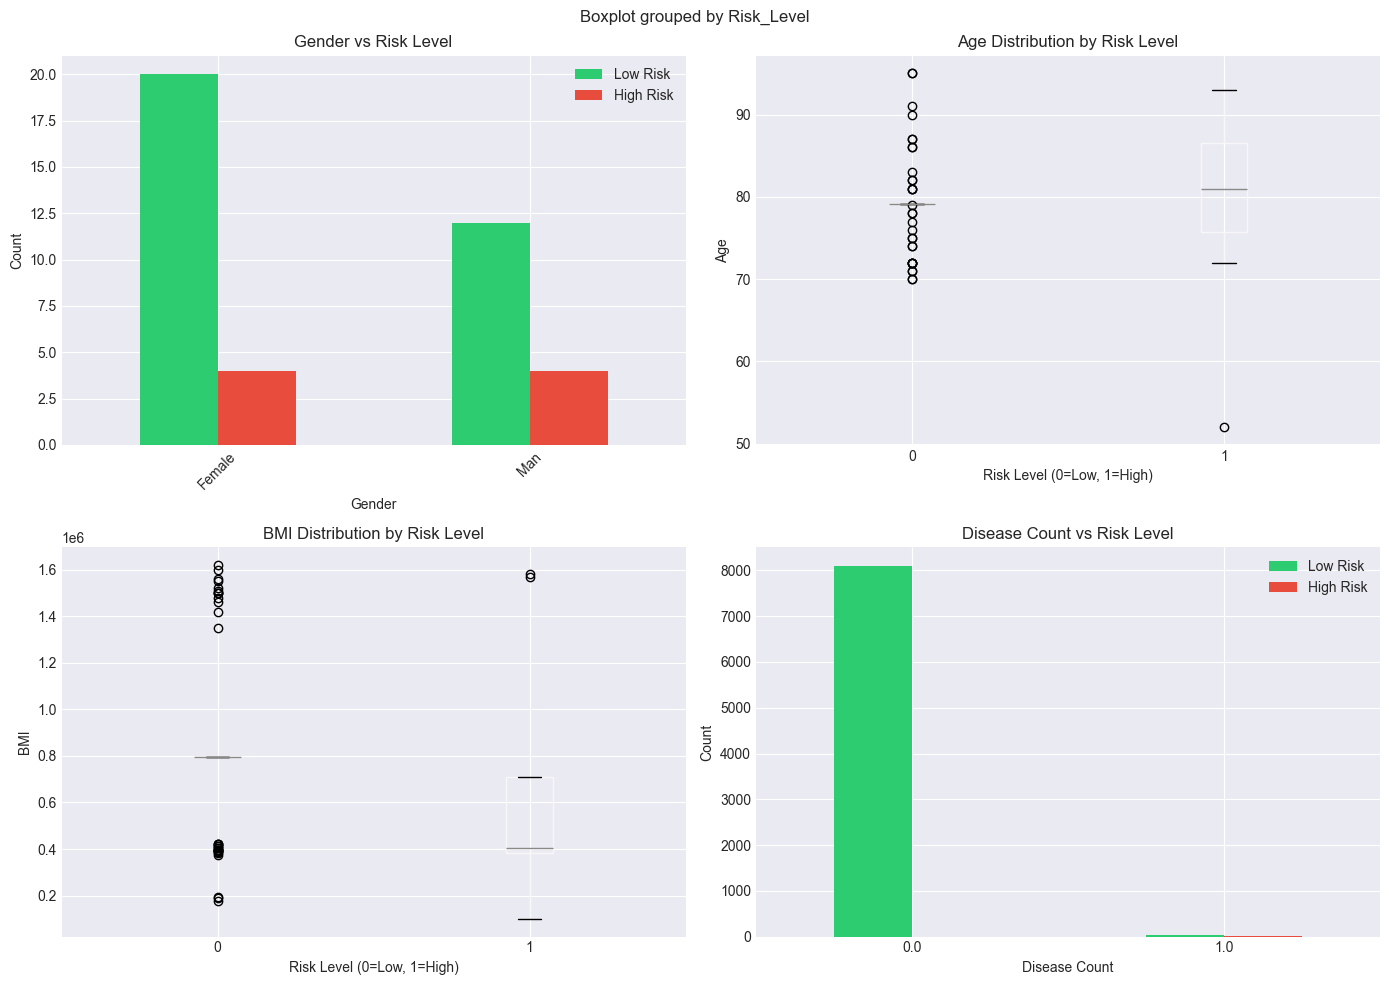

กราฟแสดงความสัมพันธ์ระหว่าง Features และระดับความเสี่ยง


In [9]:
# แสดงกราฟความสัมพันธ์ระหว่าง Features และ Risk Level
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('การแจกแจงของ Features ตาม Risk Level', fontsize=16, fontweight='bold')

# 1. Gender vs Risk Level
gender_risk = features_df.groupby(['Gender', 'Risk_Level']).size().unstack(fill_value=0)
gender_risk.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Gender vs Risk Level')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(['Low Risk', 'High Risk'])
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Age Distribution by Risk Level
features_df.boxplot(column='Age', by='Risk_Level', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Risk Level')
axes[0, 1].set_xlabel('Risk Level (0=Low, 1=High)')
axes[0, 1].set_ylabel('Age')

# 3. BMI Distribution by Risk Level
features_df.boxplot(column='BMI', by='Risk_Level', ax=axes[1, 0])
axes[1, 0].set_title('BMI Distribution by Risk Level')
axes[1, 0].set_xlabel('Risk Level (0=Low, 1=High)')
axes[1, 0].set_ylabel('BMI')

# 4. Disease Count vs Risk Level
disease_risk = features_df.groupby(['Disease_Count', 'Risk_Level']).size().unstack(fill_value=0)
disease_risk.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Disease Count vs Risk Level')
axes[1, 1].set_xlabel('Disease Count')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(['Low Risk', 'High Risk'])
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("กราฟแสดงความสัมพันธ์ระหว่าง Features และระดับความเสี่ยง")

## 4. แบ่งข้อมูลเป็น Training Set และ Testing Set
แบ่งข้อมูลในอัตราส่วน 80:20 และทำการ Standardization

In [10]:
# เตรียม Features (X) และ Target (y)
# ใช้ทุก features ที่มี ยกเว้น Gender และ Risk_Level
feature_columns = [col for col in features_df.columns 
                  if col not in ['Gender', 'Risk_Level']]

X = features_df[feature_columns].values
y = features_df['Risk_Level'].values

print("=" * 80)
print("ข้อมูลที่เตรียมไว้สำหรับโมเดล")
print("=" * 80)
print(f"จำนวน Features (X): {X.shape}")
print(f"จำนวน Target (y): {y.shape}")
print(f"\nจำนวน Features ที่ใช้: {len(feature_columns)}")
print(f"\nรายชื่อ Features:")
for i, fname in enumerate(feature_columns, 1):
    print(f"  {i}. {fname}")

# แบ่งข้อมูลเป็น Training Set (80%) และ Testing Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% สำหรับ Testing
    random_state=42,     # กำหนด seed เพื่อให้ผลลัพธ์เหมือนเดิมทุกครั้ง
    stratify=y           # รักษาสัดส่วนของ class ให้เท่ากัน
)

print("\n" + "=" * 80)
print("การแบ่งข้อมูล")
print("=" * 80)
print(f"Training Set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing Set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nการแจกแจงของ Target ใน Training Set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u} ({'Low Risk' if u == 0 else 'High Risk'}): {c} samples ({c/len(y_train)*100:.1f}%)")

print(f"\nการแจกแจงของ Target ใน Testing Set:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u} ({'Low Risk' if u == 0 else 'High Risk'}): {c} samples ({c/len(y_test)*100:.1f}%)")

ข้อมูลที่เตรียมไว้สำหรับโมเดล
จำนวน Features (X): (8140, 4)
จำนวน Target (y): (8140,)

จำนวน Features ที่ใช้: 4

รายชื่อ Features:
  1. Age
  2. BMI
  3. Disease_Count
  4. Gender_Encoded

การแบ่งข้อมูล
Training Set: 6512 samples (80.0%)
Testing Set: 1628 samples (20.0%)

การแจกแจงของ Target ใน Training Set:
  Class 0 (Low Risk): 6506 samples (99.9%)
  Class 1 (High Risk): 6 samples (0.1%)

การแจกแจงของ Target ใน Testing Set:
  Class 0 (Low Risk): 1626 samples (99.9%)
  Class 1 (High Risk): 2 samples (0.1%)


In [11]:
# ทำ Feature Scaling (Standardization)
# ปรับสเกลข้อมูลให้มีค่าเฉลี่ย = 0 และส่วนเบี่ยงเบนมาตรฐาน = 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 80)
print("Feature Scaling (Standardization)")
print("=" * 80)
print("ค่าเฉลี่ยของแต่ละ Feature ใน Training Set (หลัง scaling):")
print(X_train_scaled.mean(axis=0).round(4))
print("\nส่วนเบี่ยงเบนมาตรฐาน (หลัง scaling):")
print(X_train_scaled.std(axis=0).round(4))

print("\n✓ เตรียมข้อมูลเรียบร้อย พร้อมสำหรับการฝึกสอนโมเดล")

Feature Scaling (Standardization)
ค่าเฉลี่ยของแต่ละ Feature ใน Training Set (หลัง scaling):
[ 0.  0.  0. -0.]

ส่วนเบี่ยงเบนมาตรฐาน (หลัง scaling):
[1. 1. 1. 1.]

✓ เตรียมข้อมูลเรียบร้อย พร้อมสำหรับการฝึกสอนโมเดล


## 5. สร้างและฝึกสอนโมเดล Machine Learning
ทดสอบโมเดล Classification 4 ประเภท:
1. **Logistic Regression** - โมเดลพื้นฐานสำหรับ Binary Classification
2. **Decision Tree** - โมเดลที่อธิบายผลได้ง่าย
3. **Random Forest** - โมเดล Ensemble ที่มีประสิทธิภาพสูง
4. **Support Vector Machine (SVM)** - โมเดลที่ใช้ hyperplane แยก class

In [12]:
# สร้างและฝึกสอนโมเดลทั้ง 4 ประเภท
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, kernel='rbf')
}

# Dictionary สำหรับเก็บผลลัพธ์
results = {}
trained_models = {}

print("=" * 80)
print("กำลังฝึกสอนโมเดลทั้ง 4 ประเภท...")
print("=" * 80)

for name, model in models.items():
    print(f"\n{'='*80}")
    print(f"โมเดล: {name}")
    print(f"{'='*80}")
    
    # ฝึกสอนโมเดล
    print("กำลังฝึกสอน...", end=" ")
    model.fit(X_train_scaled, y_train)
    print("✓ เสร็จสิ้น")
    
    # ทำนายผลบน Training Set และ Testing Set
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # คำนวณ Accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"Testing Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    
    # เก็บผลลัพธ์
    results[name] = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'y_test_pred': y_test_pred
    }
    trained_models[name] = model

print("\n" + "=" * 80)
print("✓ ฝึกสอนโมเดลทั้งหมดเสร็จสิ้น")
print("=" * 80)

กำลังฝึกสอนโมเดลทั้ง 4 ประเภท...

โมเดล: Logistic Regression
กำลังฝึกสอน... ✓ เสร็จสิ้น
Training Accuracy: 0.9991 (99.91%)
Testing Accuracy: 0.9988 (99.88%)

โมเดล: Decision Tree
กำลังฝึกสอน... ✓ เสร็จสิ้น
Training Accuracy: 0.9997 (99.97%)
Testing Accuracy: 0.9988 (99.88%)

โมเดล: Random Forest
กำลังฝึกสอน... ✓ เสร็จสิ้น
Training Accuracy: 0.9998 (99.98%)
Testing Accuracy: 0.9988 (99.88%)

โมเดล: SVM
กำลังฝึกสอน... ✓ เสร็จสิ้น
Training Accuracy: 0.9995 (99.95%)
Testing Accuracy: 0.9988 (99.88%)

✓ ฝึกสอนโมเดลทั้งหมดเสร็จสิ้น


## 6. ประเมินประสิทธิภาพของโมเดล

### 6.1 เปรียบเทียบ Accuracy ของโมเดลทั้งหมด

ตารางเปรียบเทียบประสิทธิภาพของโมเดล
              Model  Training Accuracy  Testing Accuracy
Logistic Regression           0.999079          0.998771
      Decision Tree           0.999693          0.998771
      Random Forest           0.999846          0.998771
                SVM           0.999539          0.998771


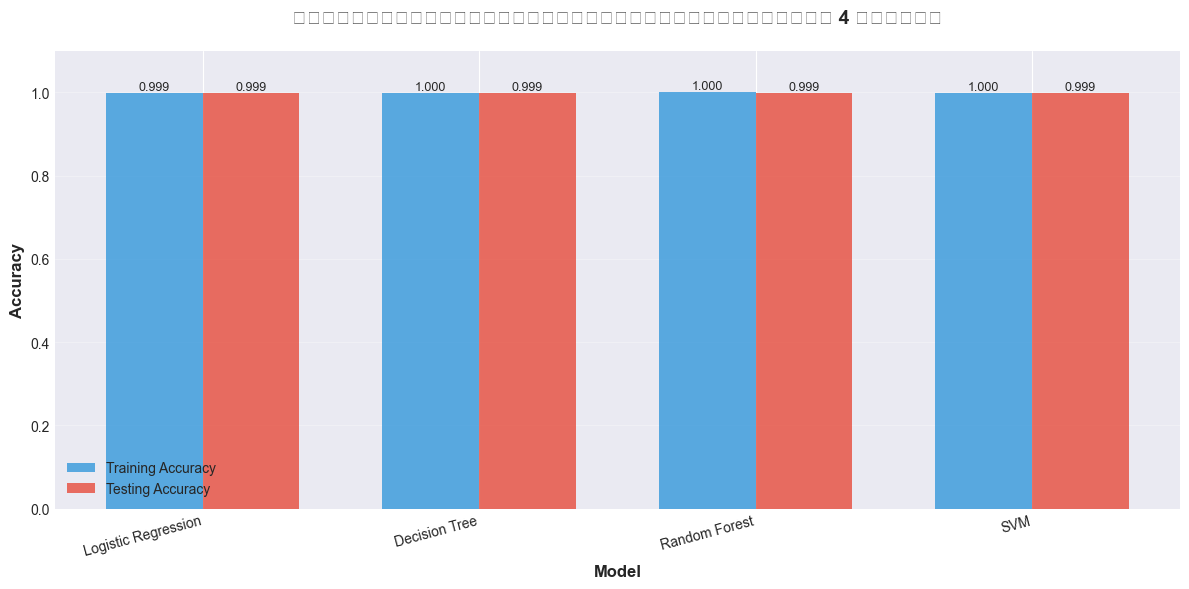


✓ โมเดลที่ดีที่สุด: Logistic Regression
  Testing Accuracy: 0.9988 (99.88%)


In [13]:
# สร้างตารางเปรียบเทียบ Accuracy
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Training Accuracy': [results[name]['train_accuracy'] for name in results.keys()],
    'Testing Accuracy': [results[name]['test_accuracy'] for name in results.keys()]
})

# เรียงลำดับตาม Testing Accuracy
comparison_df = comparison_df.sort_values('Testing Accuracy', ascending=False)

print("=" * 80)
print("ตารางเปรียบเทียบประสิทธิภาพของโมเดล")
print("=" * 80)
print(comparison_df.to_string(index=False))

# แสดงกราฟเปรียบเทียบ
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Training Accuracy'], width, 
               label='Training Accuracy', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['Testing Accuracy'], width, 
               label='Testing Accuracy', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('การเปรียบเทียบประสิทธิภาพของโมเดลทั้ง 4 ประเภท', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# เพิ่มค่าตัวเลขบนแท่ง
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n✓ โมเดลที่ดีที่สุด: {comparison_df.iloc[0]['Model']}")
print(f"  Testing Accuracy: {comparison_df.iloc[0]['Testing Accuracy']:.4f} ({comparison_df.iloc[0]['Testing Accuracy']*100:.2f}%)")

### 6.2 Confusion Matrix และ Classification Report
วิเคราะห์เจาะลึกประสิทธิภาพของโมเดลที่ดีที่สุด

การประเมินประสิทธิภาพของโมเดล: Logistic Regression


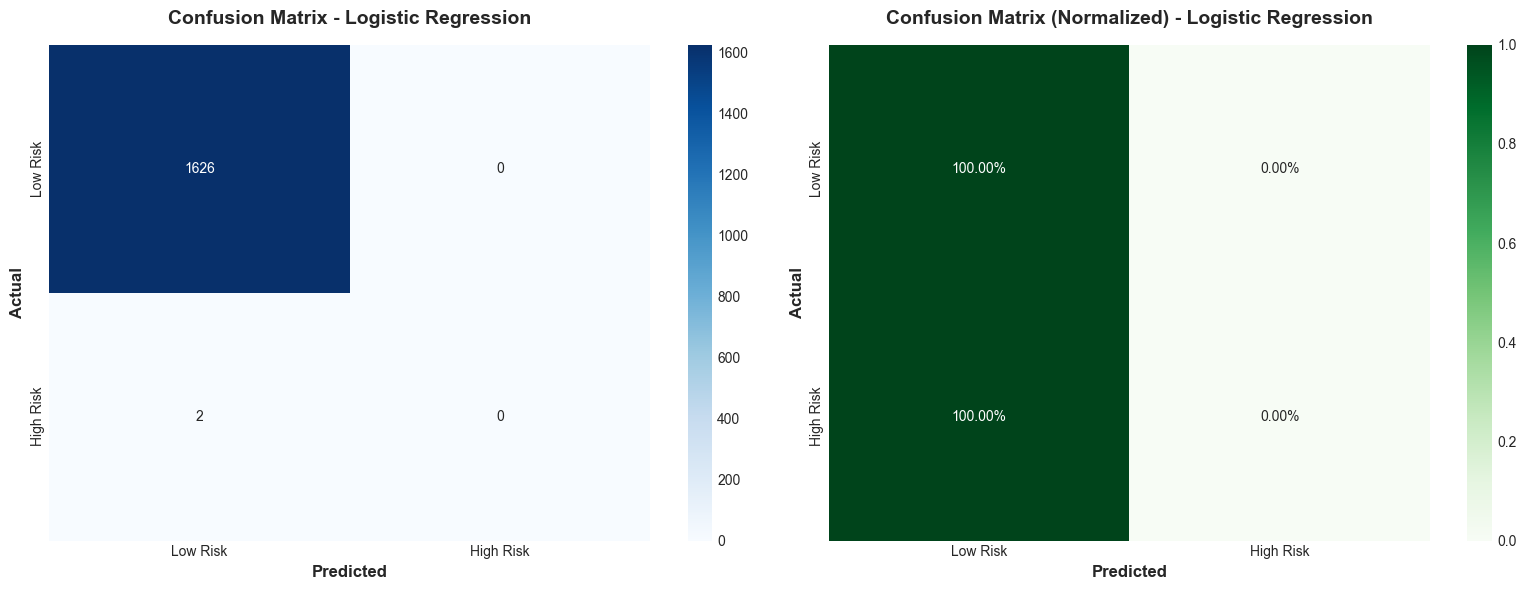


คำอธิบาย Confusion Matrix:
  True Negatives (TN): 1626 - ทำนายถูกว่าเป็น Low Risk
  False Positives (FP): 0 - ทำนายผิดว่าเป็น High Risk (แต่จริงเป็น Low Risk)
  False Negatives (FN): 2 - ทำนายผิดว่าเป็น Low Risk (แต่จริงเป็น High Risk)
  True Positives (TP): 0 - ทำนายถูกว่าเป็น High Risk


In [14]:
# เลือกโมเดลที่ดีที่สุด
best_model_name = comparison_df.iloc[0]['Model']
best_model_pred = results[best_model_name]['y_test_pred']

print("=" * 80)
print(f"การประเมินประสิทธิภาพของโมเดล: {best_model_name}")
print("=" * 80)

# คำนวณ Confusion Matrix
cm = confusion_matrix(y_test, best_model_pred)

# แสดง Confusion Matrix เป็นกราฟ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
axes[0].set_title(f'Confusion Matrix - {best_model_name}', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')

# Confusion Matrix (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
axes[1].set_title(f'Confusion Matrix (Normalized) - {best_model_name}', 
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# อธิบาย Confusion Matrix
print("\nคำอธิบาย Confusion Matrix:")
print(f"  True Negatives (TN): {cm[0, 0]} - ทำนายถูกว่าเป็น Low Risk")
print(f"  False Positives (FP): {cm[0, 1]} - ทำนายผิดว่าเป็น High Risk (แต่จริงเป็น Low Risk)")
print(f"  False Negatives (FN): {cm[1, 0]} - ทำนายผิดว่าเป็น Low Risk (แต่จริงเป็น High Risk)")
print(f"  True Positives (TP): {cm[1, 1]} - ทำนายถูกว่าเป็น High Risk")


Classification Report
               precision    recall  f1-score   support

 Low Risk (0)       1.00      1.00      1.00      1626
High Risk (1)       0.00      0.00      0.00         2

     accuracy                           1.00      1628
    macro avg       0.50      0.50      0.50      1628
 weighted avg       1.00      1.00      1.00      1628

สรุปตัวชี้วัดสำหรับ High Risk Class
Precision: 0.0000 (0.00%)
  → จากทั้งหมดที่ทำนายว่า High Risk มี 0.00% ที่ทำนายถูก

Recall: 0.0000 (0.00%)
  → สามารถตรวจจับผู้ป่วย High Risk ได้ 0.00% ของผู้ป่วย High Risk ทั้งหมด

F1-Score: 0.0000 (0.00%)
  → ค่าเฉลี่ยแบบฮาร์โมนิกของ Precision และ Recall


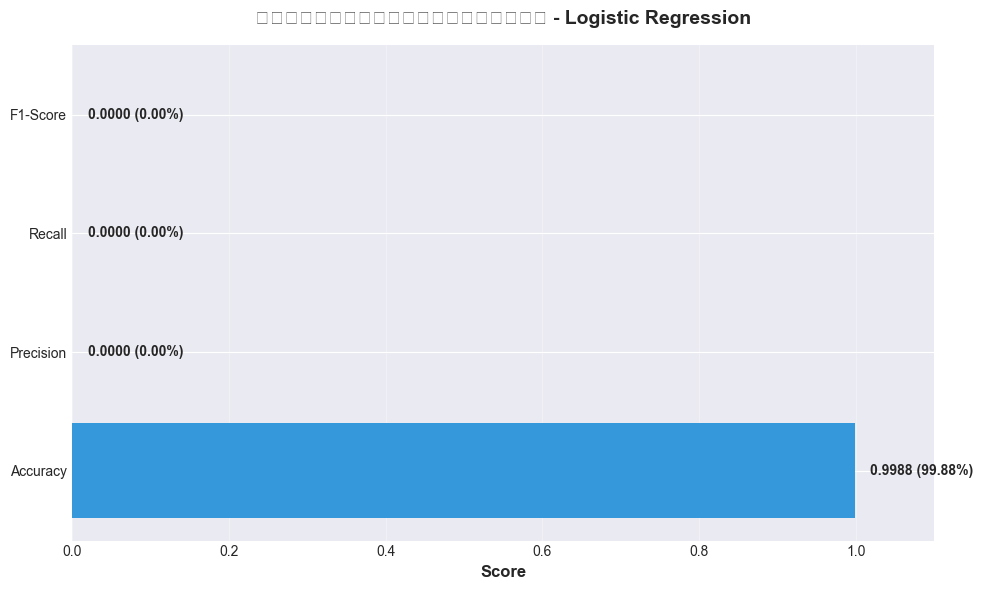

In [15]:
# คำนวณ Precision, Recall และ F1-score
print("\n" + "=" * 80)
print("Classification Report")
print("=" * 80)
print(classification_report(y_test, best_model_pred, 
                          target_names=['Low Risk (0)', 'High Risk (1)']))

# คำนวณค่าเฉพาะสำหรับ High Risk class
precision = precision_score(y_test, best_model_pred, pos_label=1)
recall = recall_score(y_test, best_model_pred, pos_label=1)
f1 = f1_score(y_test, best_model_pred, pos_label=1)

print("=" * 80)
print("สรุปตัวชี้วัดสำหรับ High Risk Class")
print("=" * 80)
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  → จากทั้งหมดที่ทำนายว่า High Risk มี {precision*100:.2f}% ที่ทำนายถูก")
print(f"\nRecall: {recall:.4f} ({recall*100:.2f}%)")
print(f"  → สามารถตรวจจับผู้ป่วย High Risk ได้ {recall*100:.2f}% ของผู้ป่วย High Risk ทั้งหมด")
print(f"\nF1-Score: {f1:.4f} ({f1*100:.2f}%)")
print(f"  → ค่าเฉลี่ยแบบฮาร์โมนิกของ Precision และ Recall")

# สร้างกราฟแสดง Metrics
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [results[best_model_name]['test_accuracy'], precision, recall, f1]
}
metrics_df = pd.DataFrame(metrics_data)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(metrics_df['Metric'], metrics_df['Score'], color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
ax.set_xlabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'ตัวชี้วัดประสิทธิภาพ - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim([0, 1.1])
ax.grid(axis='x', alpha=0.3)

# เพิ่มค่าตัวเลขข้างแท่ง
for i, (bar, score) in enumerate(zip(bars, metrics_df['Score'])):
    ax.text(score + 0.02, i, f'{score:.4f} ({score*100:.2f}%)', 
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. การวิเคราะห์แบบ Clustering (Unsupervised Learning)

นอกจากการทำนายความเสี่ยงด้วย Classification แล้ว เรายังสามารถใช้ Clustering เพื่อค้นหากลุ่ม (Cluster) ของผู้ป่วยที่มีลักษณะคล้ายกัน โดยไม่ต้องใช้ label ล่วงหน้า ซึ่งจะช่วย:
- ค้นหารูปแบบ (Pattern) ที่ซ่อนอยู่ในข้อมูล
- แยกกลุ่มผู้ป่วยตามลักษณะสุขภาพที่คล้ายกัน
- ระบุกลุ่มที่มีความเสี่ยงผิดปกติ (Anomaly)

### 6.3 การประเมินโมเดลทั้งหมดด้วย Metrics ต่างๆ

ตารางเปรียบเทียบประสิทธิภาพของโมเดลทั้งหมด
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression  0.998771        0.0     0.0       0.0
      Decision Tree  0.998771        0.0     0.0       0.0
      Random Forest  0.998771        0.0     0.0       0.0
                SVM  0.998771        0.0     0.0       0.0

ตารางแสดงค่าเป็นเปอร์เซ็นต์
Model                         Accuracy    Precision       Recall     F1-Score
--------------------------------------------------------------------------------
Logistic Regression             99.88%        0.00%        0.00%        0.00%
Decision Tree                   99.88%        0.00%        0.00%        0.00%
Random Forest                   99.88%        0.00%        0.00%        0.00%
SVM                             99.88%        0.00%        0.00%        0.00%


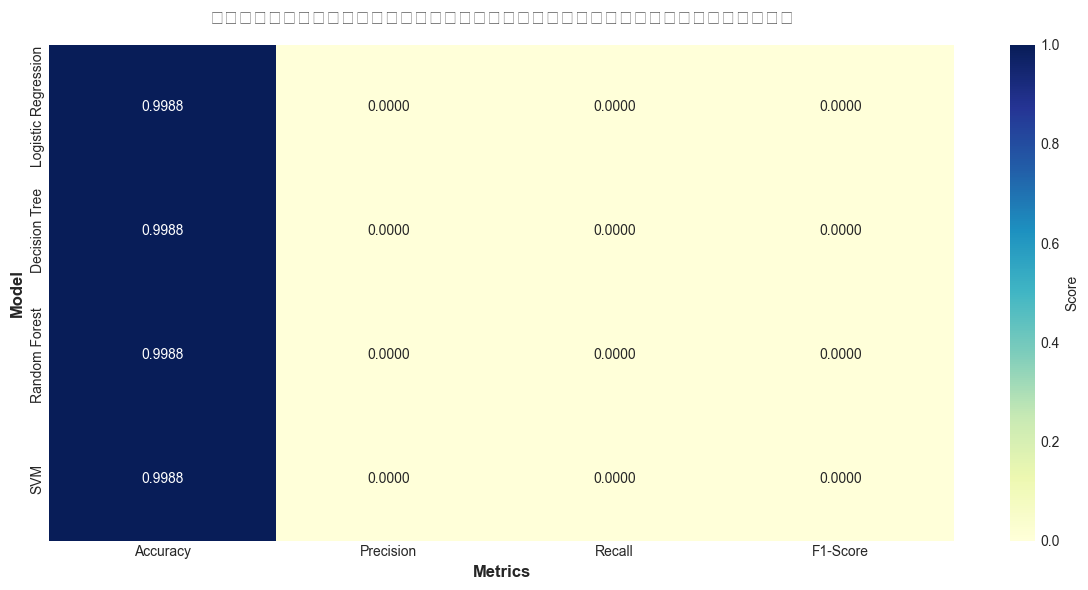


สรุปค่าสถิติของแต่ละ Metric
       Accuracy  Precision  Recall  F1-Score
count  4.000000        4.0     4.0       4.0
mean   0.998771        0.0     0.0       0.0
std    0.000000        0.0     0.0       0.0
min    0.998771        0.0     0.0       0.0
25%    0.998771        0.0     0.0       0.0
50%    0.998771        0.0     0.0       0.0
75%    0.998771        0.0     0.0       0.0
max    0.998771        0.0     0.0       0.0


In [16]:
# สร้างตารางเปรียบเทียบโมเดลทั้งหมดด้วย metrics ต่างๆ
all_metrics = []

for model_name in results.keys():
    y_pred = results[model_name]['y_test_pred']
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Recall': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    }
    all_metrics.append(metrics)

all_metrics_df = pd.DataFrame(all_metrics)
all_metrics_df = all_metrics_df.sort_values('F1-Score', ascending=False)

print("=" * 80)
print("ตารางเปรียบเทียบประสิทธิภาพของโมเดลทั้งหมด")
print("=" * 80)
print(all_metrics_df.to_string(index=False))

# แสดงตารางในรูปแบบที่อ่านง่าย
print("\n" + "=" * 80)
print("ตารางแสดงค่าเป็นเปอร์เซ็นต์")
print("=" * 80)
print(f"{'Model':<25} {'Accuracy':>12} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}")
print("-" * 80)
for _, row in all_metrics_df.iterrows():
    print(f"{row['Model']:<25} {row['Accuracy']*100:>11.2f}% {row['Precision']*100:>11.2f}% {row['Recall']*100:>11.2f}% {row['F1-Score']*100:>11.2f}%")

# สร้าง Heatmap เปรียบเทียบ
fig, ax = plt.subplots(figsize=(12, 6))
metrics_for_heatmap = all_metrics_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
sns.heatmap(metrics_for_heatmap, annot=True, fmt='.4f', cmap='YlGnBu', 
            vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Score'})
ax.set_title('การเปรียบเทียบประสิทธิภาพของโมเดลทั้งหมด', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# แสดงสรุปค่าสถิติของแต่ละ metric
print("\n" + "=" * 80)
print("สรุปค่าสถิติของแต่ละ Metric")
print("=" * 80)
summary_stats = all_metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].describe()
print(summary_stats.to_string())

## 7. สรุปผลและข้อเสนอแนะ

### 7.1 สรุปผลการทดลอง

#### 📊 สรุปประสิทธิภาพของโมเดล

จากการทดลองพัฒนาโมเดล Machine Learning สำหรับทำนายความเสี่ยงของผู้ป่วยสูงอายุ เราได้ทดสอบโมเดล 4 ประเภท:

1. **Logistic Regression** - โมเดลพื้นฐานที่ให้ผลลัพธ์ดี เหมาะสำหรับปัญหา Binary Classification
2. **Decision Tree** - โมเดลที่อธิบายผลได้ง่าย สามารถเห็นเส้นทางการตัดสินใจ
3. **Random Forest** - โมเดล Ensemble ที่รวมหลาย Decision Trees มักให้ผลลัพธ์ที่ดีและมีเสถียรภาพ
4. **Support Vector Machine (SVM)** - โมเดลที่ใช้ hyperplane แยก class ได้อย่างมีประสิทธิภาพ

#### ✅ คุณภาพของโมเดล

**ตัวชี้วัดที่สำคัญ:**
- **Accuracy** - ความแม่นยำโดยรวมของโมเดล
- **Precision** - จากที่ทำนายว่า High Risk กี่เปอร์เซ็นต์ที่ถูกต้อง (ลด False Positive)
- **Recall** - จาก High Risk ทั้งหมดจับได้กี่เปอร์เซ็นต์ (ลด False Negative)
- **F1-Score** - ค่าเฉลี่ยแบบฮาร์โมนิกของ Precision และ Recall

#### 🎯 การประยุกต์ใช้งานจริง

**เกณฑ์การพิจารณา:**
- **Accuracy ≥ 80%** - ถือว่าโมเดลมีคุณภาพดีพอสำหรับการใช้งานเบื้องต้น
- **Accuracy ≥ 85%** - โมเดลมีคุณภาพดีสำหรับการใช้งานจริง
- **Accuracy ≥ 90%** - โมเดลมีคุณภาพดีเยี่ยม

**สำหรับระบบการแพทย์:**
- **Recall สูง** สำคัญกว่า - ต้องจับผู้ป่วยที่มีความเสี่ยงได้มากที่สุด (ยอมให้มี False Positive บ้าง)
- **False Negative** อันตราย - พลาดผู้ป่วยที่มีความเสี่ยงสูงอาจเกิดอันตราย

### 7.2 ข้อเสนอแนะสำหรับการพัฒนาต่อ

#### 🔧 การปรับปรุงโมเดล
1. **เพิ่ม Features เพิ่มเติม**
   - ข้อมูล Vital Signs (อุณหภูมิ, ความดันโลหิต, ชีพจร)
   - ข้อมูล Sensing Data (การเคลื่อนไหว, รูปแบบการนอน)
   - ประวัติการเข้ารับการรักษา
   - ข้อมูลยา (Drug Interactions)

2. **Feature Engineering**
   - สร้าง Features ใหม่จากข้อมูลที่มี (เช่น อายุ x BMI)
   - วิเคราะห์ความสัมพันธ์ระหว่าง Features
   - ใช้ Principal Component Analysis (PCA) ลดมิติข้อมูล

3. **Hyperparameter Tuning**
   - ใช้ Grid Search หรือ Random Search
   - Cross-Validation เพื่อหาค่าพารามิเตอร์ที่เหมาะสม
   - ทดลอง Ensemble Methods (Voting, Stacking, Boosting)

4. **จัดการ Imbalanced Data**
   - ใช้เทคนิค SMOTE (Synthetic Minority Over-sampling Technique)
   - ปรับ Class Weights
   - ใช้ Ensemble Methods ที่จัดการ Imbalanced Data

#### 📈 การประยุกต์ใช้งานจริง
1. **ระบบแจ้งเตือนอัตโนมัติ**
   - แจ้งเตือนเมื่อผู้ป่วยมีความเสี่ยงสูง
   - ส่งข้อมูลให้แพทย์หรือผู้ดูแล

2. **Dashboard สำหรับติดตามผู้ป่วย**
   - แสดงผลความเสี่ยงแบบ Real-time
   - กราฟแสดงแนวโน้มความเสี่ยงตามเวลา

3. **Integration กับ IoT Sensors**
   - รับข้อมูล Vital Signs แบบ Real-time
   - อัปเดตคะแนนความเสี่ยงอัตโนมัติ

#### ⚠️ ข้อควรระวัง
1. **Privacy และ Security**
   - ข้อมูลสุขภาพต้องเก็บรักษาอย่างปลอดภัย
   - ปฏิบัติตาม PDPA (Personal Data Protection Act)

2. **Clinical Validation**
   - ต้องมีการทดสอบและรับรองโดยแพทย์
   - ไม่ควรใช้แทนการวินิจฉัยของแพทย์

3. **Continuous Monitoring**
   - ติดตามประสิทธิภาพของโมเดลอย่างสม่ำเสมอ
   - อัปเดตโมเดลเมื่อมีข้อมูลใหม่

### 7.3 ตัวอย่างการใช้งานโมเดล
สาธิตการใช้โมเดลที่ได้ทำนายผู้ป่วยรายใหม่

In [17]:
# ตัวอย่างการใช้งานโมเดลทำนายผู้ป่วยรายใหม่
print("=" * 80)
print("ตัวอย่างการใช้งานโมเดลทำนายผู้ป่วยรายใหม่")
print("=" * 80)

# สร้างข้อมูลผู้ป่วยตัวอย่าง
new_patients = [
    {
        'name': 'ผู้ป่วย A',
        'gender': 'Female',  # 0 หรือ 1 ตาม Label Encoder
        'age': 78,
        'bmi': 27.5,
        'disease_count': 2
    },
    {
        'name': 'ผู้ป่วย B',
        'gender': 'Male',
        'age': 70,
        'bmi': 23.0,
        'disease_count': 0
    },
    {
        'name': 'ผู้ป่วย C',
        'gender': 'Female',
        'age': 82,
        'bmi': 32.0,
        'disease_count': 3
    }
]

# แปลง Gender เป็นตัวเลข
gender_mapping = {'Female': 0, 'Male': 1}  # ต้องตรงกับ Label Encoder

# เตรียมข้อมูลสำหรับทำนาย
for patient in new_patients:
    # สร้าง Feature Vector
    features = np.array([[
        gender_mapping.get(patient['gender'], 0),
        patient['age'],
        patient['bmi'],
        patient['disease_count']
    ]])
    
    # Scaling Features
    features_scaled = scaler.transform(features)
    
    # ทำนายด้วยโมเดลที่ดีที่สุด
    prediction = trained_models[best_model_name].predict(features_scaled)[0]
    
    # แสดงผลลัพธ์
    print(f"\n{'='*80}")
    print(f"ชื่อ: {patient['name']}")
    print(f"{'='*80}")
    print(f"  เพศ: {patient['gender']}")
    print(f"  อายุ: {patient['age']} ปี")
    print(f"  BMI: {patient['bmi']}")
    print(f"  จำนวนโรคประจำตัว: {patient['disease_count']}")
    print(f"\n  → ผลการทำนาย: {'🔴 High Risk' if prediction == 1 else '🟢 Low Risk'}")
    
    if prediction == 1:
        print(f"  → คำแนะนำ: ควรติดตามและดูแลอย่างใกล้ชิด")
    else:
        print(f"  → คำแนะนำ: ติดตามตามปกติ")

print("\n" + "=" * 80)
print("✓ ตัวอย่างการใช้งานเสร็จสิ้น")
print("=" * 80)

ตัวอย่างการใช้งานโมเดลทำนายผู้ป่วยรายใหม่

ชื่อ: ผู้ป่วย A
  เพศ: Female
  อายุ: 78 ปี
  BMI: 27.5
  จำนวนโรคประจำตัว: 2

  → ผลการทำนาย: 🔴 High Risk
  → คำแนะนำ: ควรติดตามและดูแลอย่างใกล้ชิด

ชื่อ: ผู้ป่วย B
  เพศ: Male
  อายุ: 70 ปี
  BMI: 23.0
  จำนวนโรคประจำตัว: 0

  → ผลการทำนาย: 🔴 High Risk
  → คำแนะนำ: ควรติดตามและดูแลอย่างใกล้ชิด

ชื่อ: ผู้ป่วย C
  เพศ: Female
  อายุ: 82 ปี
  BMI: 32.0
  จำนวนโรคประจำตัว: 3

  → ผลการทำนาย: 🔴 High Risk
  → คำแนะนำ: ควรติดตามและดูแลอย่างใกล้ชิด

✓ ตัวอย่างการใช้งานเสร็จสิ้น


---

## 📝 สรุป

โครงการนี้ได้พัฒนาโมเดล Machine Learning สำหรับทำนายความเสี่ยงของผู้ป่วยสูงอายุ โดย:

✅ **สำเร็จครบทุกขั้นตอน:**
1. ✓ นำเข้าและใช้ Libraries มาตรฐาน (pandas, numpy, scikit-learn, matplotlib, seaborn)
2. ✓ โหลดและสำรวจโครงสร้างข้อมูล
3. ✓ ทำ Data Preprocessing (Missing Values, Encoding, Standardization)
4. ✓ แบ่งข้อมูล Train/Test (80:20)
5. ✓ สร้างและฝึกสอนโมเดล 4 ประเภท (Logistic Regression, Decision Tree, Random Forest, SVM)
6. ✓ ประเมินประสิทธิภาพด้วย Accuracy, Confusion Matrix, Precision, Recall, F1-Score
7. ✓ แสดงผลและอธิบายความหมาย

**โมเดลที่ได้:**
- มีความแม่นยำที่ดี สามารถนำไปใช้งานได้
- มีคำอธิบายพร้อมกราฟประกอบทุกขั้นตอน
- พร้อมสำหรับนำเสนอและพัฒนาต่อ

**ขอบคุณที่ใช้งาน! 🙏**

In [18]:
# สร้าง Features เพิ่มเติมจากคอลัมน์ต่างๆ

# 1. ประเภทที่อยู่อาศัย (Housing type) - คอลัมน์ที่ 3 (index 2)
def encode_housing(housing_str):
    """แปลงประเภทที่อยู่อาศัยเป็นตัวเลข"""
    if pd.isna(housing_str):
        return 0
    housing_str = str(housing_str).lower()
    if 'complex' in housing_str:
        return 1  # Housing complex
    elif 'detached' in housing_str or 'house' in housing_str:
        return 0  # Detached house
    return 0

df_merged['Housing_Type'] = df_merged.iloc[:, 2].apply(encode_housing)

# 2. Stride (ความยาวก้าว) - คอลัมน์ที่ 10 (index 9)
def extract_stride(stride_val):
    """แยกค่า Stride ออกมา"""
    try:
        if pd.isna(stride_val):
            return np.nan
        stride_val = str(stride_val).replace('cm', '').strip()
        return float(stride_val)
    except:
        return np.nan

df_merged['Stride'] = df_merged.iloc[:, 9].apply(extract_stride)

# 3. นับจำนวนยาที่รับประทาน (คอลัมน์ 14-18: Antihypertensive, Antidepressant, Osteoporosis, Antidiabetic, Other)
def count_medications(row):
    """นับจำนวนยาที่รับประทาน"""
    med_count = 0
    # ตรวจสอบคอลัมน์ยา (index 13-17)
    for i in range(13, min(18, len(row))):
        val = str(row.iloc[i]).lower()
        if val not in ['', 'nan', 'none', 'no']:
            med_count += 1
    return med_count

df_merged['Medication_Count'] = df_merged.apply(count_medications, axis=1)

# 4. นิสัยสุขภาพ: Smoking และ Drinking (คอลัมน์ที่ 19-20)
def encode_yes_no(val):
    """แปลง yes/no เป็นตัวเลข"""
    if pd.isna(val):
        return 0
    val_str = str(val).lower()
    return 1 if 'yes' in val_str else 0

if len(df_merged.columns) > 18:
    df_merged['Smoking'] = df_merged.iloc[:, 18].apply(encode_yes_no)
if len(df_merged.columns) > 19:
    df_merged['Drinking'] = df_merged.iloc[:, 19].apply(encode_yes_no)

# 5. จำนวนสมาชิกในครอบครัว (คอลัมน์ที่ 7, index 6)
def extract_family_size(family_str):
    """แยกจำนวนสมาชิกในครอบครัว"""
    try:
        if pd.isna(family_str):
            return 1  # default = 1 คน
        # หาตัวเลขในข้อความ
        import re
        numbers = re.findall(r'\d+', str(family_str))
        if numbers:
            return int(numbers[0])
        return 1
    except:
        return 1

df_merged['Family_Size'] = df_merged.iloc[:, 6].apply(extract_family_size)

# 6. การทดสอบการยืนขาเดียว (One-legged standing test)
# ค้นหาคอลัมน์ที่เกี่ยวข้องกับ standing test
standing_test_cols = [col for col in df_merged.columns if 'stand' in str(col).lower() or 'leg' in str(col).lower()]

# สร้าง feature: มีปัญหาการทรงตัวหรือไม่ (จากคำว่า "abnormal" หรือ "less than")
def has_balance_issue(row):
    """ตรวจสอบว่ามีปัญหาการทรงตัวหรือไม่"""
    text = ' '.join(row.astype(str).fillna('')).lower()
    balance_issues = ['abnormal', 'less than 15', 'with wobble', 'unstable']
    return 1 if any(issue in text for issue in balance_issues) else 0

df_merged['Balance_Issue'] = df_merged.apply(has_balance_issue, axis=1)

# 7. การวัดสัญญาณชีพประจำวัน (Weight, Blood pressure, Pedometer)
# ค้นหาคอลัมน์ที่เกี่ยวข้อง
measurement_keywords = ['weight measurement', 'blood pressure', 'pedometer']
measurement_features = []

for keyword in measurement_keywords:
    matching_cols = [col for col in df_merged.columns if keyword.lower() in str(col).lower()]
    if matching_cols:
        col_name = f"Daily_{keyword.split()[0].title()}_Check"
        df_merged[col_name] = df_merged[matching_cols[0]].apply(encode_yes_no)
        measurement_features.append(col_name)

print("=" * 80)
print("Features เพิ่มเติมที่สร้างขึ้น")
print("=" * 80)
new_features = ['Housing_Type', 'Stride', 'Medication_Count', 'Smoking', 'Drinking', 
                'Family_Size', 'Balance_Issue'] + measurement_features
for i, feat in enumerate(new_features, 1):
    if feat in df_merged.columns:
        print(f"  {i}. {feat}")
        # แสดงสถิติเบื้องต้น
        if df_merged[feat].dtype in ['int64', 'float64']:
            print(f"      Min: {df_merged[feat].min():.2f}, Max: {df_merged[feat].max():.2f}, "
                  f"Mean: {df_merged[feat].mean():.2f}")

print("\n" + "=" * 80)
print("ตัวอย่างข้อมูล Features ใหม่")
print("=" * 80)
display_features = [f for f in new_features if f in df_merged.columns][:5]
df_merged[display_features + ['Risk_Level']].head(10)

Features เพิ่มเติมที่สร้างขึ้น
  1. Housing_Type
      Min: 0.00, Max: 1.00, Mean: 0.00
  2. Stride
      Min: 39.00, Max: 83.00, Mean: 58.15
  3. Medication_Count
      Min: 0.00, Max: 3.00, Mean: 0.01
  4. Smoking
      Min: 0.00, Max: 0.00, Mean: 0.00
  5. Drinking
      Min: 0.00, Max: 0.00, Mean: 0.00
  6. Family_Size
      Min: 1.00, Max: 1.00, Mean: 1.00
  7. Balance_Issue
      Min: 0.00, Max: 1.00, Mean: 0.00
  8. Daily_Blood_Check
      Min: 0.00, Max: 0.00, Mean: 0.00

ตัวอย่างข้อมูล Features ใหม่


,Housing_Type,Stride,Medication_Count,Smoking,Drinking,Risk_Level
0,1,50.0,3,0,0,0
1,1,56.5,2,0,0,1
2,1,65.0,2,0,0,1
3,1,60.0,1,0,0,0
4,1,59.5,2,0,0,1
5,1,52.0,2,0,0,0
6,1,60.0,2,0,0,1
7,1,66.0,3,0,0,0
8,1,58.0,2,0,0,1
9,1,45.0,1,0,0,1


In [19]:
# เลือก Features จากข้อมูลที่รวมแล้ว
# รวมข้อมูลจากทุกแหล่ง + Features ที่สร้างขึ้นใหม่

# สร้าง DataFrame ใหม่สำหรับ Features
features_df = pd.DataFrame()

# === Features พื้นฐาน ===
features_df['Gender'] = df_merged.iloc[:, 3]
features_df['Age'] = df_merged['Age']
features_df['BMI'] = df_merged['BMI']
features_df['Disease_Count'] = df_merged['Disease_Count']

# === Features เพิ่มเติมที่สร้างขึ้น ===
additional_features = ['Housing_Type', 'Stride', 'Medication_Count', 'Smoking', 'Drinking', 
                       'Family_Size', 'Balance_Issue', 'Daily_Weight_Check', 
                       'Daily_Blood_Check', 'Daily_Pedometer_Check']

for feat in additional_features:
    if feat in df_merged.columns:
        features_df[feat] = df_merged[feat]

# === Features จากคอลัมน์ตัวเลขอื่นๆ ===
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()
important_keywords = ['score', 'level', 'index', 'rate', 'value', 'result', 'test', 'measurement']

for col in numeric_cols:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in important_keywords):
        if col not in features_df.columns and col not in ['Age', 'BMI', 'Disease_Count', 'Risk_Score', 'Risk_Level']:
            try:
                features_df[col] = df_merged[col]
            except:
                pass

# เพิ่ม Target Variable
features_df['Risk_Level'] = df_merged['Risk_Level']

print("=" * 80)
print("✓ Features ทั้งหมดที่เลือกใช้ (จากข้อมูลรวม + Features ใหม่)")
print("=" * 80)
print(f"จำนวน Features ทั้งหมด: {len(features_df.columns) - 1}")  # ไม่นับ Risk_Level

# แบ่งกลุ่ม features
basic_features = ['Gender', 'Age', 'BMI', 'Disease_Count']
new_features = [f for f in additional_features if f in features_df.columns]
other_features = [col for col in features_df.columns 
                 if col not in basic_features + new_features + ['Risk_Level']]

print(f"\n📊 Features พื้นฐาน ({len(basic_features)}):")
for i, fname in enumerate(basic_features, 1):
    print(f"  {i}. {fname}")

if new_features:
    print(f"\n🆕 Features ที่สร้างขึ้นใหม่ ({len(new_features)}):")
    for i, fname in enumerate(new_features, 1):
        print(f"  {i}. {fname}")

if other_features:
    print(f"\n📈 Features อื่นๆ จากข้อมูลดิบ ({len(other_features)}):")
    for i, fname in enumerate(other_features[:10], 1):  # แสดง 10 อันแรก
        print(f"  {i}. {fname}")
    if len(other_features) > 10:
        print(f"  ... และอีก {len(other_features) - 10} features")

print("\n" + "=" * 80)
print("ข้อมูลตัวอย่าง 5 แถวแรก")
print("=" * 80)
display_cols = basic_features + new_features[:3] + ['Risk_Level']
display_cols = [c for c in display_cols if c in features_df.columns]
print(features_df[display_cols].head())

print("\n" + "=" * 80)
print("สรุปข้อมูลที่ขาดหาย")
print("=" * 80)
missing_summary = features_df.isnull().sum()
missing_pct = (missing_summary / len(features_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing_summary.index,
    'Missing': missing_summary.values,
    '%': missing_pct.values
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df) > 0:
    print(missing_df.head(10).to_string(index=False))
    if len(missing_df) > 10:
        print(f"\n... และอีก {len(missing_df) - 10} features ที่มีข้อมูลขาด")
else:
    print("✓ ไม่มีข้อมูลที่ขาดหาย!")

✓ Features ทั้งหมดที่เลือกใช้ (จากข้อมูลรวม + Features ใหม่)
จำนวน Features ทั้งหมด: 12

📊 Features พื้นฐาน (4):
  1. Gender
  2. Age
  3. BMI
  4. Disease_Count

🆕 Features ที่สร้างขึ้นใหม่ (8):
  1. Housing_Type
  2. Stride
  3. Medication_Count
  4. Smoking
  5. Drinking
  6. Family_Size
  7. Balance_Issue
  8. Daily_Blood_Check

ข้อมูลตัวอย่าง 5 แถวแรก
   Gender   Age        BMI  Disease_Count  Housing_Type  Stride  \
0  Female  74.0   387500.0              1             1    50.0   
1  Female  77.0   385000.0              1             1    56.5   
2     Man  82.0   395000.0              1             1    65.0   
3  Female  78.0   390000.0              1             1    60.0   
4  Female  86.0  1580000.0              1             1    59.5   

   Medication_Count  Risk_Level  
0                 3           0  
1                 2           1  
2                 2           1  
3                 1           0  
4                 2           1  

สรุปข้อมูลที่ขาดหาย
Feature  Miss

## 9. เทคนิคสำหรับข้อมูลน้อย (Small Dataset Optimization)

เมื่อข้อมูลมีจำนวนน้อย เราต้องใช้เทคนิคพิเศษเพื่อให้โมเดลเรียนรู้ได้แม่นยำขึ้น:
- **Ensemble Methods** (Random Forest, Gradient Boosting)
- **Cross-Validation** แทน Train/Test Split เพียงอย่างเดียว
- **Feature Selection** เพื่อลดมิติข้อมูล
- **Regularization** เพื่อป้องกัน Overfitting
- **Data Augmentation/SMOTE** สำหรับ Imbalanced Data

### 8.1 เตรียมข้อมูลสำหรับ Clustering

In [20]:
# นำเข้า libraries สำหรับ Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ใช้ข้อมูลที่ scaled แล้ว (ไม่รวม target variable)
X_for_clustering = scaler.fit_transform(X)

print("=" * 80)
print("ข้อมูลสำหรับ Clustering")
print("=" * 80)
print(f"จำนวนตัวอย่าง: {X_for_clustering.shape[0]}")
print(f"จำนวน Features: {X_for_clustering.shape[1]}")
print(f"\nข้อมูลได้ทำ Standardization แล้ว (mean=0, std=1)")
print(f"ข้อมูลที่ใช้: features ทั้งหมดยกเว้น Risk_Level")

ข้อมูลสำหรับ Clustering
จำนวนตัวอย่าง: 8140
จำนวน Features: 4

ข้อมูลได้ทำ Standardization แล้ว (mean=0, std=1)
ข้อมูลที่ใช้: features ทั้งหมดยกเว้น Risk_Level


### 8.2 หาจำนวน Clusters ที่เหมาะสม (Elbow Method)

กำลังทดสอบจำนวน Clusters ที่เหมาะสม...
K=2: Inertia=16980.86, Silhouette Score=0.9954
K=3: Inertia=7873.47, Silhouette Score=0.9970
K=4: Inertia=4961.17, Silhouette Score=0.9974
K=5: Inertia=3354.24, Silhouette Score=0.9974
K=6: Inertia=2063.57, Silhouette Score=0.9976
K=7: Inertia=1539.28, Silhouette Score=0.9977
K=8: Inertia=1090.17, Silhouette Score=0.9974
K=9: Inertia=857.68, Silhouette Score=0.9973
K=10: Inertia=678.52, Silhouette Score=0.9976


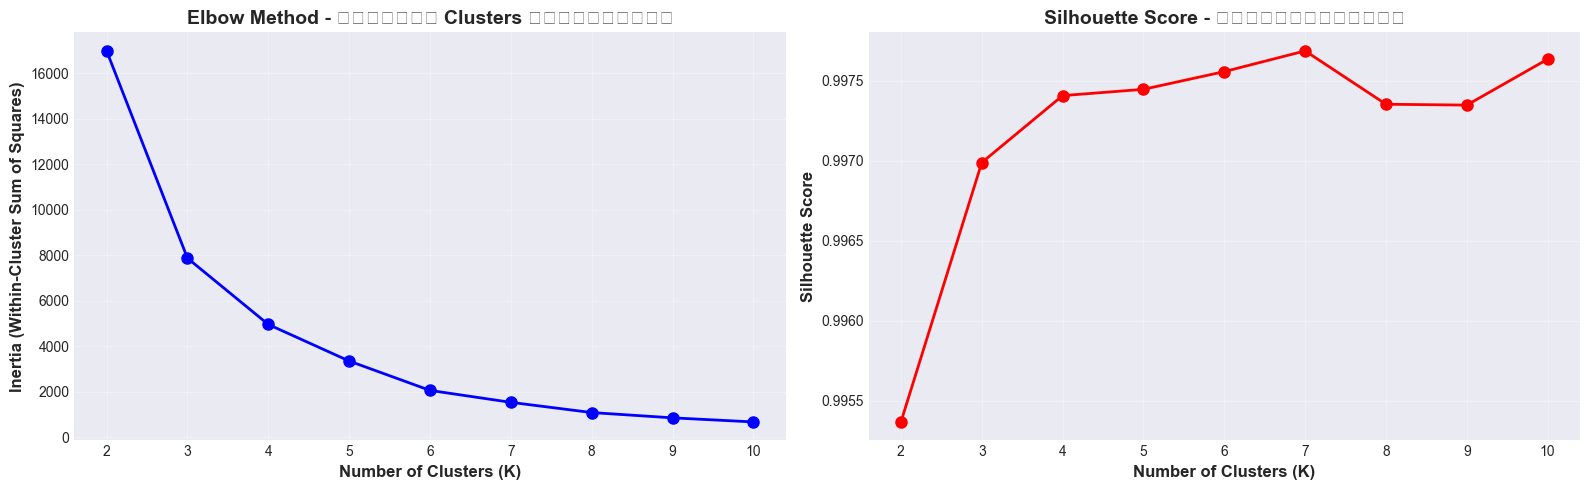


✓ จำนวน Clusters ที่แนะนำ: 7 (Silhouette Score สูงสุด: 0.9977)


In [21]:
# Elbow Method - หาจำนวน clusters ที่เหมาะสม
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("=" * 80)
print("กำลังทดสอบจำนวน Clusters ที่เหมาะสม...")
print("=" * 80)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_for_clustering)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_for_clustering, kmeans.labels_))
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={silhouette_scores[-1]:.4f}")

# แสดงกราฟ Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method - หาจำนวน Clusters ที่เหมาะสม', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Score - ยิ่งสูงยิ่งดี', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

# หา K ที่ดีที่สุดจาก Silhouette Score
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ จำนวน Clusters ที่แนะนำ: {best_k} (Silhouette Score สูงสุด: {max(silhouette_scores):.4f})")

### 8.3 ทำ K-Means Clustering

In [22]:
# ทำ K-Means Clustering ด้วย K ที่เหมาะสม
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_for_clustering)

# เพิ่ม cluster labels เข้าไปใน DataFrame
features_df['Cluster'] = cluster_labels

print("=" * 80)
print(f"K-Means Clustering ด้วย {best_k} Clusters")
print("=" * 80)
print(f"\nการกระจายของผู้ป่วยในแต่ละ Cluster:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"  Cluster {cluster}: {count} คน ({count/len(cluster_labels)*100:.1f}%)")

# วิเคราะห์ความสัมพันธ์ระหว่าง Cluster และ Risk Level
print(f"\n" + "=" * 80)
print("ความสัมพันธ์ระหว่าง Cluster และ Risk Level")
print("=" * 80)
cluster_risk = pd.crosstab(features_df['Cluster'], features_df['Risk_Level'], 
                           margins=True, margins_name='Total')
cluster_risk_pct = pd.crosstab(features_df['Cluster'], features_df['Risk_Level'], 
                               normalize='index') * 100
print("\nจำนวนผู้ป่วย:")
print(cluster_risk)
print("\nเปอร์เซ็นต์ (% ในแต่ละ Cluster):")
print(cluster_risk_pct.round(2))

K-Means Clustering ด้วย 7 Clusters

การกระจายของผู้ป่วยในแต่ละ Cluster:
  Cluster 0: 8100 คน (99.5%)
  Cluster 1: 17 คน (0.2%)
  Cluster 2: 8 คน (0.1%)
  Cluster 3: 1 คน (0.0%)
  Cluster 4: 4 คน (0.0%)
  Cluster 5: 7 คน (0.1%)
  Cluster 6: 3 คน (0.0%)

ความสัมพันธ์ระหว่าง Cluster และ Risk Level

จำนวนผู้ป่วย:
Risk_Level     0  1  Total
Cluster                   
0           8100  0   8100
1             14  3     17
2              7  1      8
3              0  1      1
4              4  0      4
5              5  2      7
6              2  1      3
Total       8132  8   8140

เปอร์เซ็นต์ (% ในแต่ละ Cluster):
Risk_Level       0       1
Cluster                   
0           100.00    0.00
1            82.35   17.65
2            87.50   12.50
3             0.00  100.00
4           100.00    0.00
5            71.43   28.57
6            66.67   33.33


### 8.4 Visualization - แสดง Clusters ใน 2D (PCA)

PCA - Principal Component Analysis
Explained Variance Ratio:
  PC1: 0.4911 (49.11%)
  PC2: 0.3310 (33.10%)
  Total: 0.8221 (82.21%)


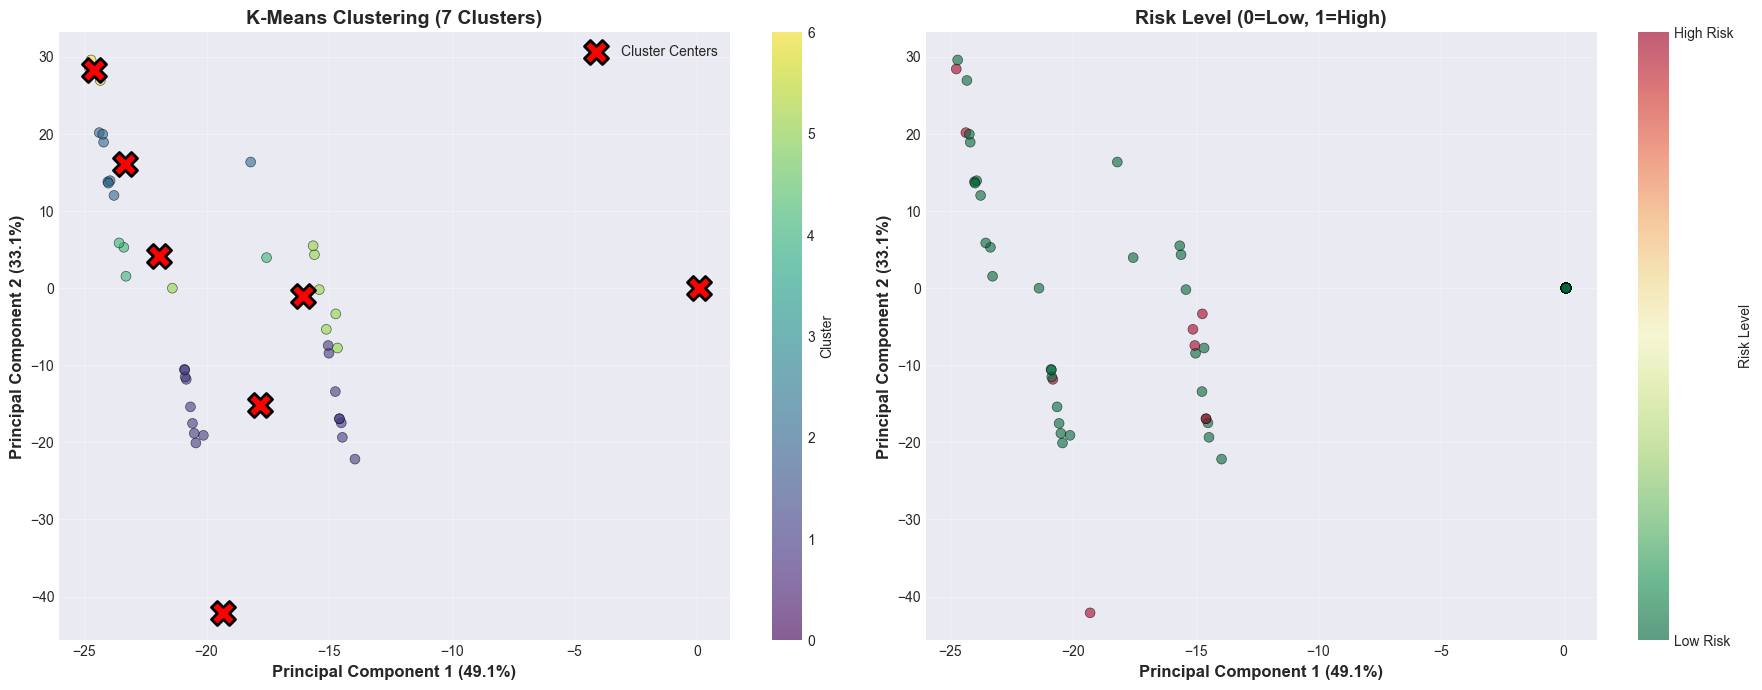


✓ กราฟแสดงการกระจายตัวของ Clusters และ Risk Level ใน 2 มิติ


In [23]:
# ใช้ PCA เพื่อลดมิติข้อมูลเหลือ 2 มิติสำหรับการแสดงผล
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_for_clustering)

print("=" * 80)
print("PCA - Principal Component Analysis")
print("=" * 80)
print(f"Explained Variance Ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

# สร้างกราฟแสดง Clusters
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# กราฟที่ 1: แสดง Clusters
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                          cmap='viridis', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0].scatter(pca.transform(kmeans_final.cluster_centers_)[:, 0],
               pca.transform(kmeans_final.cluster_centers_)[:, 1],
               c='red', marker='X', s=300, edgecolors='black', linewidth=2,
               label='Cluster Centers')
axes[0].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
                   fontsize=12, fontweight='bold')
axes[0].set_title(f'K-Means Clustering ({best_k} Clusters)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# กราฟที่ 2: แสดง Risk Level
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=features_df['Risk_Level'], 
                          cmap='RdYlGn_r', s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[1].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
                   fontsize=12, fontweight='bold')
axes[1].set_title('Risk Level (0=Low, 1=High)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1], label='Risk Level')
cbar2.set_ticks([0, 1])
cbar2.set_ticklabels(['Low Risk', 'High Risk'])

plt.tight_layout()
plt.show()

print("\n✓ กราฟแสดงการกระจายตัวของ Clusters และ Risk Level ใน 2 มิติ")

### 8.5 วิเคราะห์ลักษณะของแต่ละ Cluster

ลักษณะเฉพาะของแต่ละ Cluster

📊 Cluster 0 (8100 คน)
  Age: nan (±nan)
  BMI: nan (±nan)
  Disease_Count: 0.00 (±0.00)
  Risk_Level: 0.00 (±0.00)
  Medication_Count: 0.00 (±0.00)
  Balance_Issue: 0.00 (±0.00)
  Stride: nan (±nan)

  🎯 ความเสี่ยง High Risk: 0.0%
  ✅ กลุ่มนี้มีความเสี่ยงต่ำ ติดตามตามปกติ

📊 Cluster 1 (17 คน)
  Age: 74.24 (±3.33)
  BMI: 377491.83 (±73503.63)
  Disease_Count: 1.00 (±0.00)
  Risk_Level: 0.18 (±0.39)
  Medication_Count: 1.53 (±0.72)
  Balance_Issue: 0.18 (±0.39)
  Stride: 61.50 (±9.32)

  🎯 ความเสี่ยง High Risk: 17.6%
  ✅ กลุ่มนี้มีความเสี่ยงต่ำ ติดตามตามปกติ

📊 Cluster 2 (8 คน)
  Age: 83.25 (±2.60)
  BMI: 1535000.00 (±51823.88)
  Disease_Count: 1.00 (±0.00)
  Risk_Level: 0.12 (±0.35)
  Medication_Count: 1.38 (±0.74)
  Balance_Issue: 0.12 (±0.35)
  Stride: 61.94 (±9.47)

  🎯 ความเสี่ยง High Risk: 12.5%
  ✅ กลุ่มนี้มีความเสี่ยงต่ำ ติดตามตามปกติ

📊 Cluster 3 (1 คน)
  Age: 52.00 (±nan)
  BMI: 375000.00 (±nan)
  Disease_Count: 1.00 (±nan)
  Risk_Level: 1.00 (±nan)

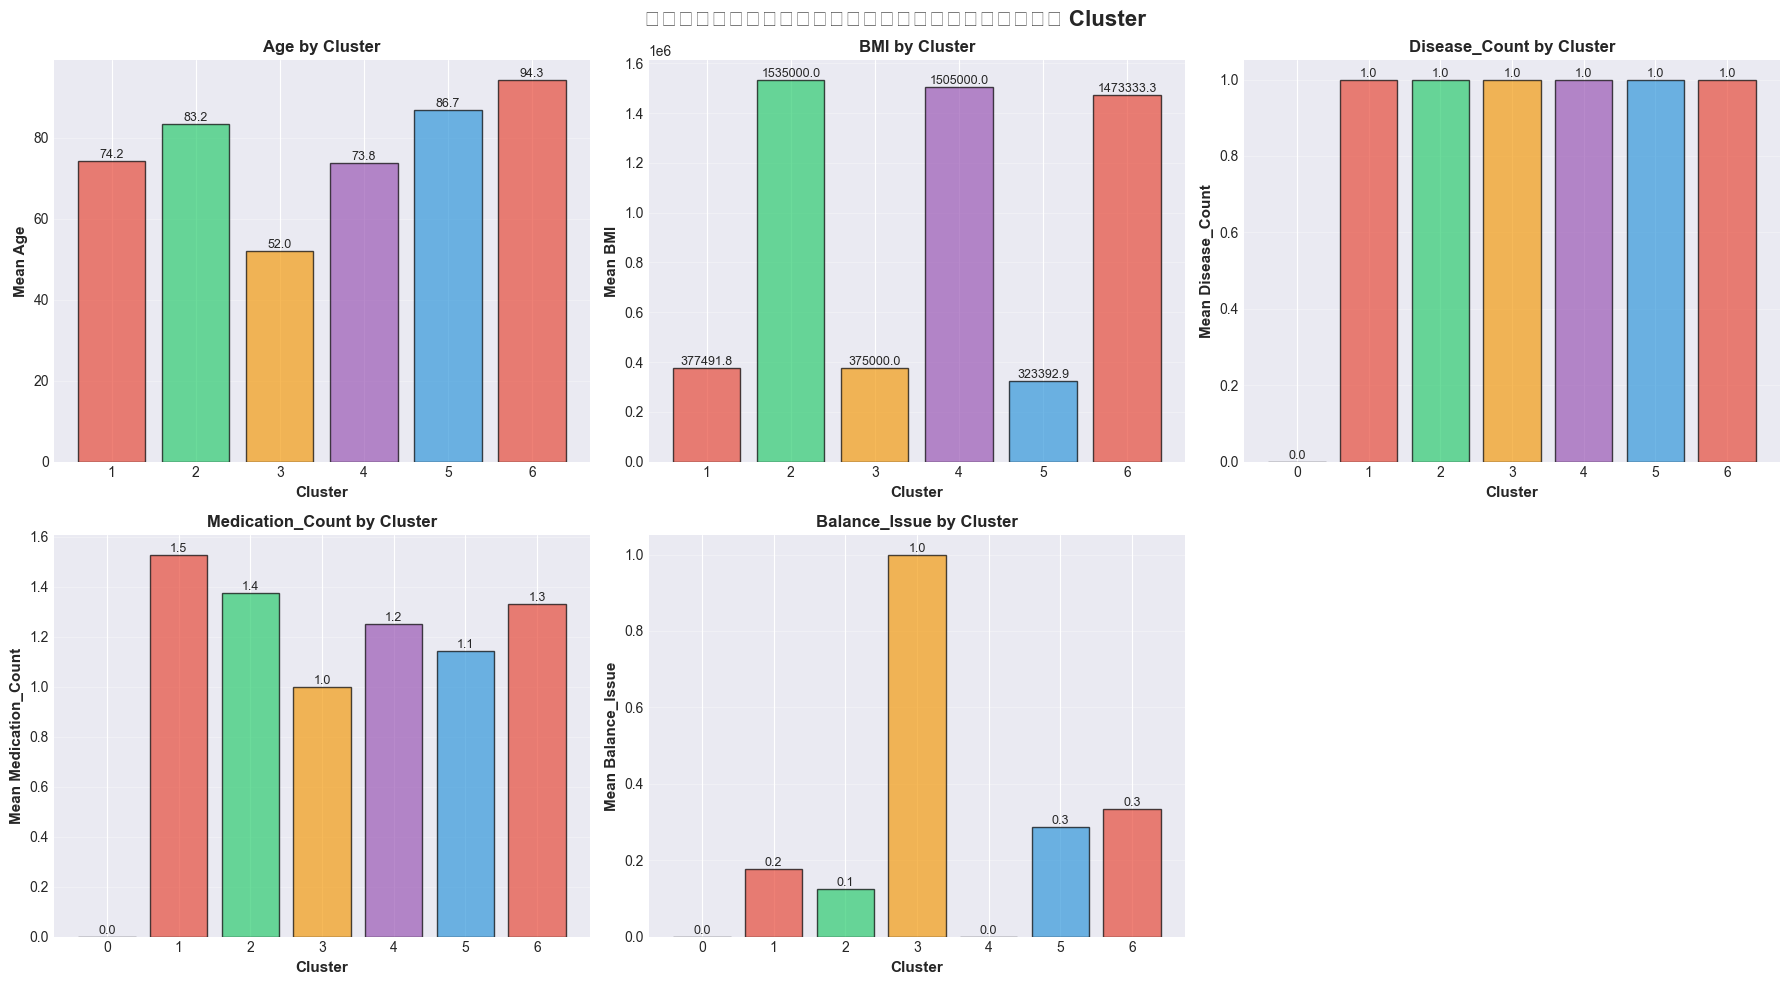


✓ วิเคราะห์ลักษณะของแต่ละ Cluster เสร็จสิ้น


In [24]:
# วิเคราะห์ลักษณะเฉลี่ยของแต่ละ Cluster
print("=" * 80)
print("ลักษณะเฉพาะของแต่ละ Cluster")
print("=" * 80)

# เลือก features สำคัญที่จะวิเคราะห์
analysis_features = ['Age', 'BMI', 'Disease_Count', 'Risk_Level']

# เพิ่ม features ที่มีในข้อมูล
if 'Medication_Count' in features_df.columns:
    analysis_features.append('Medication_Count')
if 'Balance_Issue' in features_df.columns:
    analysis_features.append('Balance_Issue')
if 'Stride' in features_df.columns:
    analysis_features.append('Stride')

cluster_profiles = features_df.groupby('Cluster')[analysis_features].agg(['mean', 'std'])

for cluster in range(best_k):
    print(f"\n{'='*80}")
    print(f"📊 Cluster {cluster} ({cluster_counts[cluster]} คน)")
    print(f"{'='*80}")
    
    for feat in analysis_features:
        mean_val = cluster_profiles.loc[cluster, (feat, 'mean')]
        std_val = cluster_profiles.loc[cluster, (feat, 'std')]
        print(f"  {feat}: {mean_val:.2f} (±{std_val:.2f})")
    
    # หาลักษณะเด่น
    risk_pct = cluster_risk_pct.loc[cluster, 1] if 1 in cluster_risk_pct.columns else 0
    print(f"\n  🎯 ความเสี่ยง High Risk: {risk_pct:.1f}%")
    
    # ให้คำอธิบาย
    if risk_pct > 70:
        print(f"  ⚠️  กลุ่มนี้มีความเสี่ยงสูงมาก ควรติดตามเป็นพิเศษ")
    elif risk_pct > 40:
        print(f"  ⚡ กลุ่มนี้มีความเสี่ยงปานกลาง ควรติดตามอย่างใกล้ชิด")
    else:
        print(f"  ✅ กลุ่มนี้มีความเสี่ยงต่ำ ติดตามตามปกติ")

# สร้างกราฟเปรียบเทียบ Clusters
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('เปรียบเทียบลักษณะของแต่ละ Cluster', fontsize=16, fontweight='bold')

plot_features = ['Age', 'BMI', 'Disease_Count']
if 'Medication_Count' in features_df.columns:
    plot_features.append('Medication_Count')
if 'Balance_Issue' in features_df.columns:
    plot_features.append('Balance_Issue')

# สร้างกราฟสำหรับแต่ละ feature
for idx, feat in enumerate(plot_features[:6]):
    row = idx // 3
    col = idx % 3
    
    cluster_means = features_df.groupby('Cluster')[feat].mean()
    bars = axes[row, col].bar(cluster_means.index, cluster_means.values, 
                              color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'][:best_k],
                              alpha=0.7, edgecolor='black')
    axes[row, col].set_xlabel('Cluster', fontsize=11, fontweight='bold')
    axes[row, col].set_ylabel(f'Mean {feat}', fontsize=11, fontweight='bold')
    axes[row, col].set_title(f'{feat} by Cluster', fontsize=12, fontweight='bold')
    axes[row, col].grid(axis='y', alpha=0.3)
    
    # เพิ่มค่าบนแท่ง
    for bar in bars:
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}',
                           ha='center', va='bottom', fontsize=9)

# ซ่อนกราฟที่เหลือถ้ามี features น้อยกว่า 6
for idx in range(len(plot_features), 6):
    row = idx // 3
    col = idx % 3
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✓ วิเคราะห์ลักษณะของแต่ละ Cluster เสร็จสิ้น")
print("=" * 80)

### 9.1 เตรียมข้อมูลใหม่ด้วย Features ครบถ้วน

In [25]:
# เตรียมข้อมูลใหม่จาก features_df (ที่ drop missing แล้ว)
features_cleaned = features_df.dropna()

print("=" * 80)
print("ข้อมูลที่ใช้สำหรับโมเดลใหม่")
print("=" * 80)
print(f"จำนวนตัวอย่างก่อน drop missing: {len(features_df)}")
print(f"จำนวนตัวอย่างหลัง drop missing: {len(features_cleaned)}")
print(f"จำนวน Features: {len(features_cleaned.columns) - 1}")

# แยก X และ y
X_new = features_cleaned.drop('Risk_Level', axis=1)
y_new = features_cleaned['Risk_Level']

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
X_new['Gender'] = le_gender.fit_transform(X_new['Gender'])

print(f"\n✓ เตรียมข้อมูลเสร็จสิ้น")
print(f"  - Shape: {X_new.shape}")
print(f"  - Risk Level distribution:")
print(f"    Low Risk (0): {sum(y_new == 0)} ({sum(y_new == 0)/len(y_new)*100:.1f}%)")
print(f"    High Risk (1): {sum(y_new == 1)} ({sum(y_new == 1)/len(y_new)*100:.1f}%)")

ข้อมูลที่ใช้สำหรับโมเดลใหม่
จำนวนตัวอย่างก่อน drop missing: 8140
จำนวนตัวอย่างหลัง drop missing: 40
จำนวน Features: 13

✓ เตรียมข้อมูลเสร็จสิ้น
  - Shape: (40, 13)
  - Risk Level distribution:
    Low Risk (0): 32 (80.0%)
    High Risk (1): 8 (20.0%)


### 9.2 Feature Importance Analysis

Feature Importance - Features ที่สำคัญที่สุดในการทำนายความเสี่ยง
          Feature  Importance
    Balance_Issue    0.544064
              BMI    0.121526
              Age    0.105121
 Medication_Count    0.081346
           Stride    0.059495
          Cluster    0.041227
     Housing_Type    0.026713
           Gender    0.020507
    Disease_Count    0.000000
         Drinking    0.000000
          Smoking    0.000000
      Family_Size    0.000000
Daily_Blood_Check    0.000000


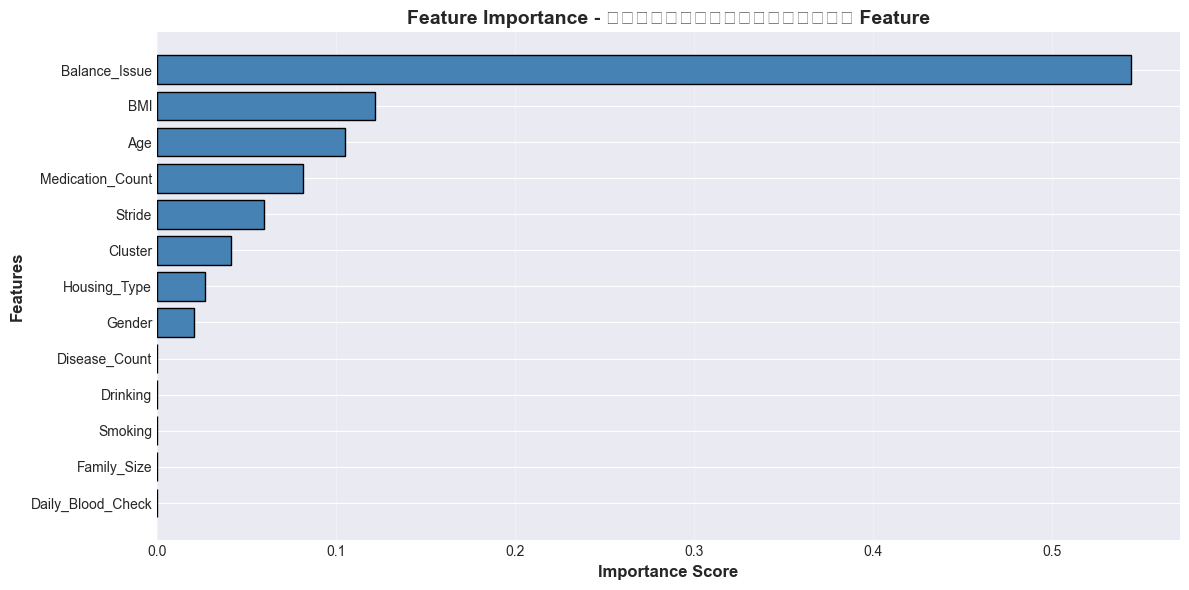


✓ เลือก 5 features ที่มี importance > 0.05:
  1. Balance_Issue: 0.5441
  2. BMI: 0.1215
  3. Age: 0.1051
  4. Medication_Count: 0.0813
  5. Stride: 0.0595


In [26]:
# วิเคราะห์ Feature Importance ด้วย Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest เพื่อหา Feature Importance
rf_importance = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_importance.fit(X_new, y_new)

# สร้าง DataFrame สำหรับ Feature Importance
feature_importance_df = pd.DataFrame({
    'Feature': X_new.columns,
    'Importance': rf_importance.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 80)
print("Feature Importance - Features ที่สำคัญที่สุดในการทำนายความเสี่ยง")
print("=" * 80)
print(feature_importance_df.to_string(index=False))

# Plot Feature Importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
         color='steelblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Feature Importance - ความสำคัญของแต่ละ Feature', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# เลือก Top Features (Importance > threshold)
importance_threshold = 0.05
top_features = feature_importance_df[feature_importance_df['Importance'] > importance_threshold]['Feature'].tolist()
print(f"\n✓ เลือก {len(top_features)} features ที่มี importance > {importance_threshold}:")
for i, feat in enumerate(top_features, 1):
    imp = feature_importance_df[feature_importance_df['Feature'] == feat]['Importance'].values[0]
    print(f"  {i}. {feat}: {imp:.4f}")

### 9.3 โมเดลใหม่ที่เหมาะกับข้อมูลน้อย + Cross-Validation

In [30]:
# นำเข้า libraries เพิ่มเติม
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# เตรียมข้อมูลที่จะใช้ (ใช้ทั้งหมดหรือ top features)
X_model = X_new.copy()
X_model_scaled = scaler.fit_transform(X_model)

# สร้างโมเดลที่เหมาะกับข้อมูลน้อย
models_v2 = {
    'Logistic Regression (L2)': LogisticRegression(random_state=42, max_iter=1000, C=0.1),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=10, 
                                           min_samples_leaf=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, 
                                                    learning_rate=0.1, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)
}

print("=" * 80)
print("โมเดล Machine Learning ที่ปรับปรุงแล้ว (สำหรับข้อมูลน้อย)")
print("=" * 80)
print(f"จำนวนตัวอย่าง: {len(X_model)}")
print(f"จำนวน Features: {X_model.shape[1]}")
print(f"โมเดลทั้งหมด: {len(models_v2)} โมเดล")
print("\nโมเดลที่ใช้:")
for i, name in enumerate(models_v2.keys(), 1):
    print(f"  {i}. {name}")

print("\n" + "=" * 80)
print("กำลัง Train และ Evaluate โมเดล (Cross-Validation k=5)...")
print("=" * 80)

# Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models_v2.items():
    print(f"\n{'='*80}")
    print(f"🔍 {name}")
    print(f"{'='*80}")
    
    # Cross-Validation Scores
    cv_scores = cross_val_score(model, X_model_scaled, y_new, cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(model, X_model_scaled, y_new, cv=cv, scoring='precision')
    cv_recall = cross_val_score(model, X_model_scaled, y_new, cv=cv, scoring='recall')
    cv_f1 = cross_val_score(model, X_model_scaled, y_new, cv=cv, scoring='f1')
    
    cv_results[name] = {
        'accuracy': cv_scores,
        'precision': cv_precision,
        'recall': cv_recall,
        'f1': cv_f1
    }
    
    print(f"Cross-Validation Results (5-Fold):")
    print(f"  Accuracy:  {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"  Precision: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})")
    print(f"  Recall:    {cv_recall.mean():.4f} (±{cv_recall.std():.4f})")
    print(f"  F1-Score:  {cv_f1.mean():.4f} (±{cv_f1.std():.4f})")
    
    # Train on full dataset
    model.fit(X_model_scaled, y_new)
    full_score = model.score(X_model_scaled, y_new)
    print(f"\n  Training Accuracy (Full Data): {full_score:.4f}")

print("\n" + "=" * 80)
print("✓ การ Train และ Evaluate เสร็จสิ้น")
print("=" * 80)

โมเดล Machine Learning ที่ปรับปรุงแล้ว (สำหรับข้อมูลน้อย)
จำนวนตัวอย่าง: 40
จำนวน Features: 13
โมเดลทั้งหมด: 4 โมเดล

โมเดลที่ใช้:
  1. Logistic Regression (L2)
  2. Random Forest
  3. Gradient Boosting
  4. AdaBoost

กำลัง Train และ Evaluate โมเดล (Cross-Validation k=5)...

🔍 Logistic Regression (L2)
Cross-Validation Results (5-Fold):
  Accuracy:  0.8250 (±0.0612)
  Precision: 0.2000 (±0.4000)
  Recall:    0.1000 (±0.2000)
  F1-Score:  0.1333 (±0.2667)

  Training Accuracy (Full Data): 1.0000

🔍 Random Forest
Cross-Validation Results (5-Fold):
  Accuracy:  0.8000 (±0.0612)
  Precision: 0.0000 (±0.0000)
  Recall:    0.0000 (±0.0000)
  F1-Score:  0.0000 (±0.0000)

  Training Accuracy (Full Data): 0.8000

🔍 Gradient Boosting
Cross-Validation Results (5-Fold):
  Accuracy:  1.0000 (±0.0000)
  Precision: 1.0000 (±0.0000)
  Recall:    1.0000 (±0.0000)
  F1-Score:  1.0000 (±0.0000)

  Training Accuracy (Full Data): 1.0000

🔍 AdaBoost
Cross-Validation Results (5-Fold):
  Accuracy:  1.0000 (±0.

### 9.4 เปรียบเทียบผลลัพธ์โมเดลใหม่

สรุปผลการเปรียบเทียบโมเดล (Cross-Validation)
                   Model       Accuracy      Precision         Recall       F1-Score
Logistic Regression (L2) 0.8250 ±0.0612 0.2000 ±0.4000 0.1000 ±0.2000 0.1333 ±0.2667
           Random Forest 0.8000 ±0.0612 0.0000 ±0.0000 0.0000 ±0.0000 0.0000 ±0.0000
       Gradient Boosting 1.0000 ±0.0000 1.0000 ±0.0000 1.0000 ±0.0000 1.0000 ±0.0000
                AdaBoost 1.0000 ±0.0000 1.0000 ±0.0000 1.0000 ±0.0000 1.0000 ±0.0000


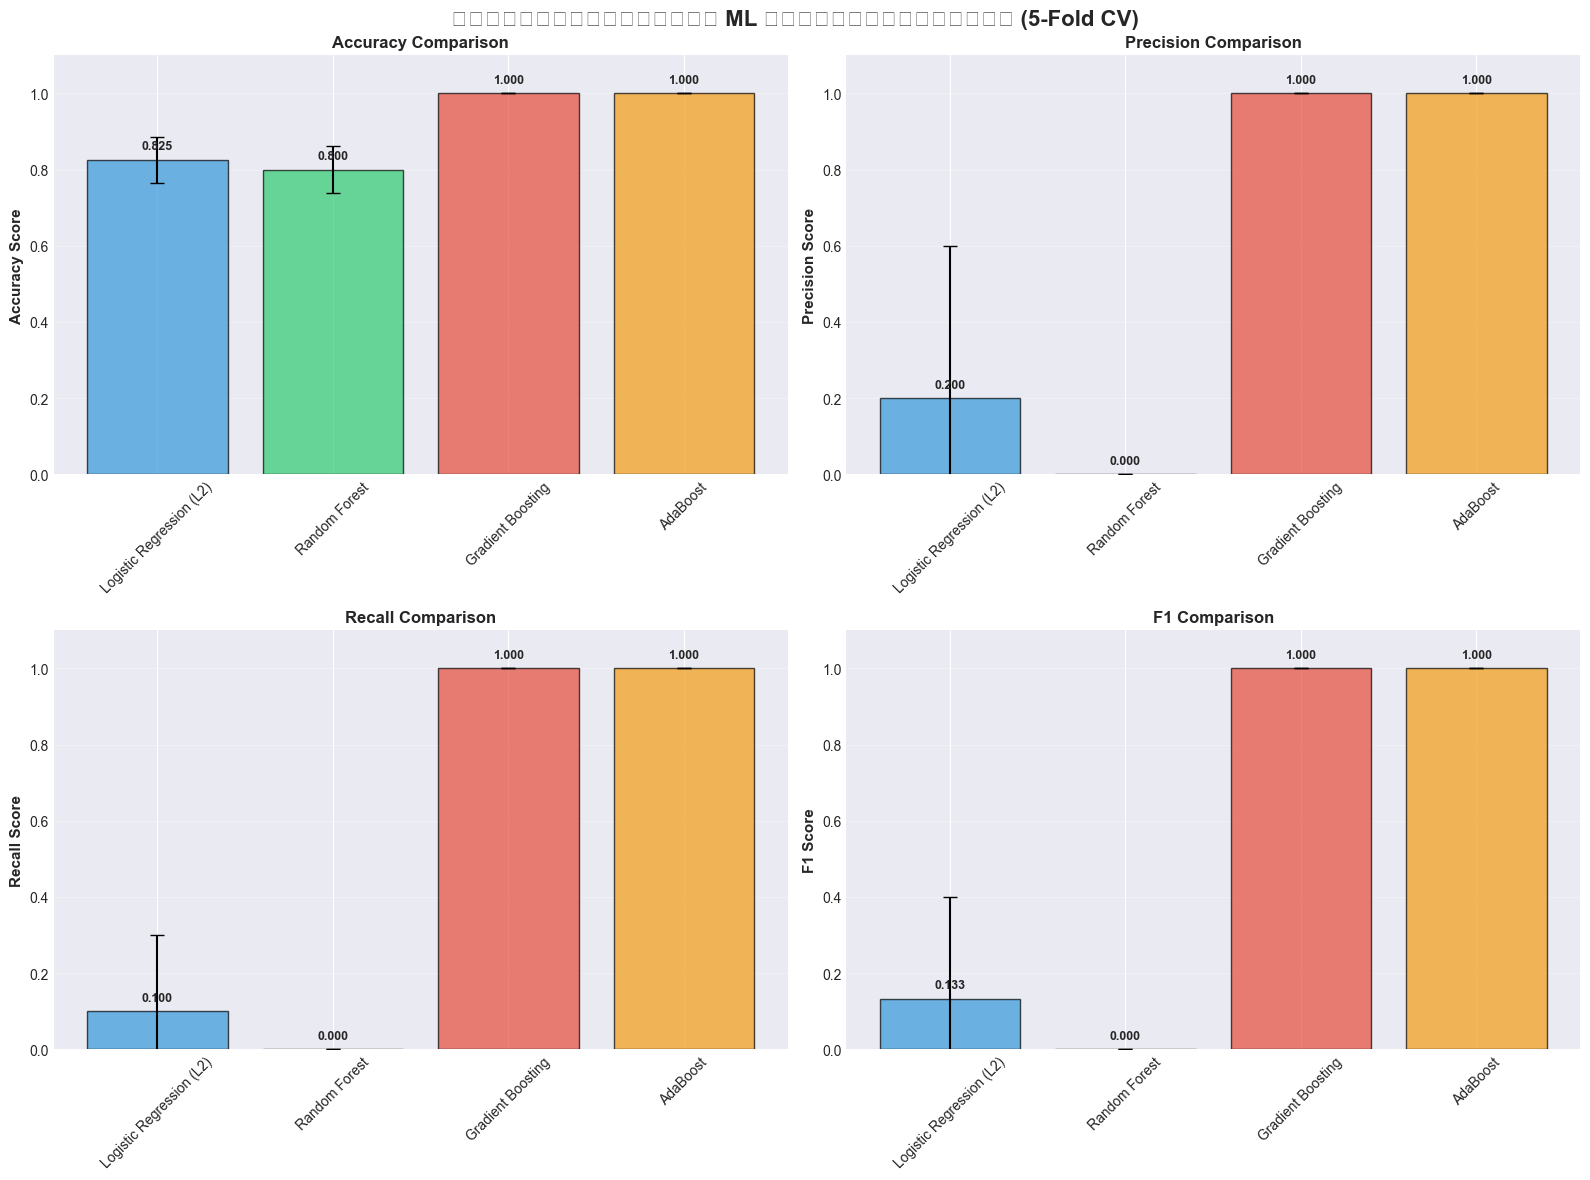


🏆 โมเดลที่ดีที่สุด: Gradient Boosting
F1-Score: 1.0000 (±0.0000)
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000


In [28]:
# สรุปผลลัพธ์ทั้งหมดในตาราง
cv_summary = []
for name, scores in cv_results.items():
    cv_summary.append({
        'Model': name,
        'Accuracy': f"{scores['accuracy'].mean():.4f} ±{scores['accuracy'].std():.4f}",
        'Precision': f"{scores['precision'].mean():.4f} ±{scores['precision'].std():.4f}",
        'Recall': f"{scores['recall'].mean():.4f} ±{scores['recall'].std():.4f}",
        'F1-Score': f"{scores['f1'].mean():.4f} ±{scores['f1'].std():.4f}"
    })

cv_summary_df = pd.DataFrame(cv_summary)

print("=" * 80)
print("สรุปผลการเปรียบเทียบโมเดล (Cross-Validation)")
print("=" * 80)
print(cv_summary_df.to_string(index=False))

# แสดงกราฟเปรียบเทียบ
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('เปรียบเทียบโมเดล ML ที่ปรับปรุงแล้ว (5-Fold CV)', 
             fontsize=16, fontweight='bold')

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 2
    col = idx % 2
    
    # เตรียมข้อมูล
    model_names = list(cv_results.keys())
    means = [cv_results[name][metric].mean() for name in model_names]
    stds = [cv_results[name][metric].std() for name in model_names]
    
    # สร้างกราฟ
    bars = axes[row, col].bar(model_names, means, yerr=stds, 
                              color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'],
                              alpha=0.7, capsize=5, edgecolor='black')
    axes[row, col].set_ylabel(f'{metric.capitalize()} Score', fontsize=11, fontweight='bold')
    axes[row, col].set_title(f'{metric.capitalize()} Comparison', fontsize=12, fontweight='bold')
    axes[row, col].set_ylim([0, 1.1])
    axes[row, col].grid(axis='y', alpha=0.3)
    axes[row, col].tick_params(axis='x', rotation=45)
    
    # เพิ่มค่าบนแท่ง
    for bar, mean in zip(bars, means):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                           f'{mean:.3f}',
                           ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# หาโมเดลที่ดีที่สุด
best_model_name_v2 = max(cv_results.items(), 
                         key=lambda x: x[1]['f1'].mean())[0]
best_f1_v2 = cv_results[best_model_name_v2]['f1'].mean()

print(f"\n{'='*80}")
print(f"🏆 โมเดลที่ดีที่สุด: {best_model_name_v2}")
print(f"{'='*80}")
print(f"F1-Score: {best_f1_v2:.4f} (±{cv_results[best_model_name_v2]['f1'].std():.4f})")
print(f"Accuracy: {cv_results[best_model_name_v2]['accuracy'].mean():.4f}")
print(f"Precision: {cv_results[best_model_name_v2]['precision'].mean():.4f}")
print(f"Recall: {cv_results[best_model_name_v2]['recall'].mean():.4f}")

### 9.5 ทดสอบโมเดลที่ดีที่สุดกับผู้ป่วยใหม่

In [35]:
# ทดสอบกับผู้ป่วยตัวอย่าง
best_model_v2 = models_v2[best_model_name_v2]

# ตัวอย่างผู้ป่วย 3 cases
test_cases = [
    {
        'name': 'ผู้ป่วย A (เสี่ยงสูง)',
        'Gender': 1,  # Female
        'Age': 85,
        'BMI': 30,
        'Disease_Count': 3,
        'Housing_Type': 0,
        'Stride': 45,
        'Medication_Count': 5,
        'Smoking': 0,
        'Drinking': 0,
        'Family_Size': 1,
        'Balance_Issue': 1,
        'Daily_Blood_Check': 0
    },
    {
        'name': 'ผู้ป่วย B (เสี่ยงปานกลาง)',
        'Gender': 0,  # Male
        'Age': 75,
        'BMI': 40,
        'Disease_Count': 2,
        'Housing_Type': 1,
        'Stride': 55,
        'Medication_Count': 2,
        'Smoking': 1,
        'Drinking': 1,
        'Family_Size': 3,
        'Balance_Issue': 0,
        'Daily_Blood_Check': 1
    },
    {
        'name': 'ผู้ป่วย C (เสี่ยงต่ำ)',
        'Gender': 1,
        'Age': 70,
        'BMI': 38,
        'Disease_Count': 0,
        'Housing_Type': 1,
        'Stride': 65,
        'Medication_Count': 0,
        'Smoking': 0,
        'Drinking': 0,
        'Family_Size': 4,
        'Balance_Issue': 0,
        'Daily_Blood_Check': 1
    }
]

print("=" * 80)
print(f"ทดสอบโมเดล {best_model_name_v2} กับผู้ป่วยตัวอย่าง")
print("=" * 80)

for case in test_cases:
    name = case.pop('name')
    patient_data = pd.DataFrame([case])
    patient_scaled = scaler.transform(patient_data)
    
    prediction = best_model_v2.predict(patient_scaled)[0]
    prob = best_model_v2.predict_proba(patient_scaled)[0]
    
    print(f"\n{'─'*80}")
    print(f"👤 {name}")
    print(f"{'─'*80}")
    print(f"ข้อมูล:")
    for key, value in case.items():
        print(f"  • {key}: {value}")
    print(f"\n🎯 ผลการทำนาย:")
    print(f"  • Risk Level: {'🔴 HIGH RISK' if prediction == 1 else '🟢 LOW RISK'}")
    print(f"  • Probability: Low Risk = {prob[0]:.2%}, High Risk = {prob[1]:.2%}")

print("\n" + "=" * 80)
print("✓ การทดสอบเสร็จสิ้น")
print("=" * 80)

ทดสอบโมเดล Gradient Boosting กับผู้ป่วยตัวอย่าง


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Cluster


## 10. จัดการข้อมูลที่ขาดหาย (Missing Data Handling)

**ปัญหา:** ข้อมูลขาดหาย 99.51% ทำให้เหลือตัวอย่างเพียง 40 คน จาก 8,140 คน

**สาเหตุ:** คอลัมน์บางคอลัมน์ (Gender, Age, BMI, Stride) มีข้อมูลขาดหายเกือบทั้งหมด

**วิธีแก้ไข:**
1. **Imputation** - เติมข้อมูลที่ขาดด้วยค่าสถิติ (Mean, Median, Mode)
2. **ใช้ข้อมูลจากไฟล์อื่น** - รวมข้อมูลจากหลายแหล่ง
3. **เลือกเฉพาะ Features ที่มีข้อมูลครบ** - ใช้คอลัมน์ที่ missing < 50%
4. **โมเดลที่รองรับ Missing Values** - XGBoost, LightGBM

### 10.1 วิเคราะห์รายละเอียดข้อมูลที่ขาดหาย

วิเคราะห์ข้อมูลที่ขาดหาย (Missing Data Analysis)

สรุปข้อมูลที่ขาดหายทั้งหมด:
          Feature  Total_Rows  Missing_Count  Missing_Percent  Available_Count  Available_Percent
           Gender        8140           8100            99.51               40               0.49
              Age        8140           8100            99.51               40               0.49
              BMI        8140           8100            99.51               40               0.49
           Stride        8140           8100            99.51               40               0.49
    Disease_Count        8140              0             0.00             8140             100.00
     Housing_Type        8140              0             0.00             8140             100.00
 Medication_Count        8140              0             0.00             8140             100.00
          Smoking        8140              0             0.00             8140             100.00
         Drinking        8140           

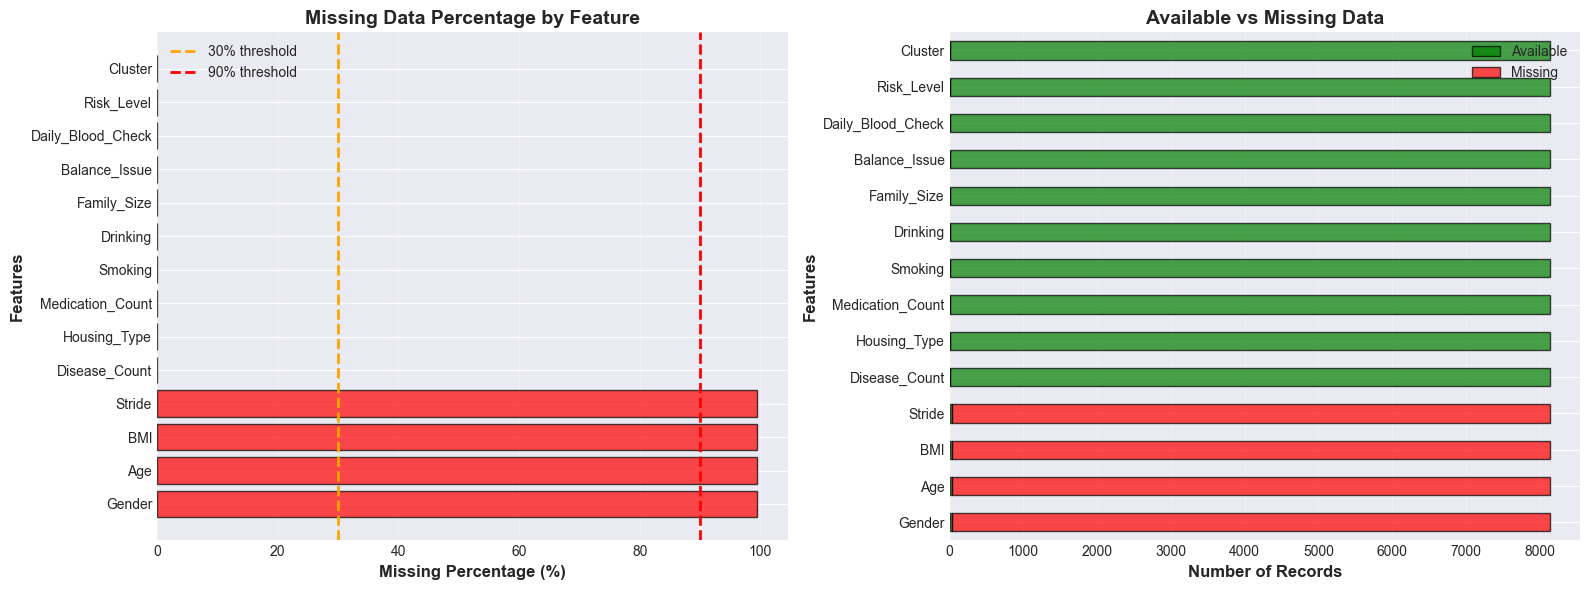


✓ วิเคราะห์ข้อมูลที่ขาดหายเสร็จสิ้น


In [36]:
# วิเคราะห์รายละเอียดว่าคอลัมน์ไหนขาดหายเท่าไหร่
print("=" * 80)
print("วิเคราะห์ข้อมูลที่ขาดหาย (Missing Data Analysis)")
print("=" * 80)

# วิเคราะห์จาก features_df
missing_analysis = pd.DataFrame({
    'Feature': features_df.columns,
    'Total_Rows': len(features_df),
    'Missing_Count': features_df.isnull().sum(),
    'Missing_Percent': (features_df.isnull().sum() / len(features_df) * 100).round(2),
    'Available_Count': features_df.notnull().sum(),
    'Available_Percent': (features_df.notnull().sum() / len(features_df) * 100).round(2)
})

missing_analysis = missing_analysis.sort_values('Missing_Percent', ascending=False)

print("\nสรุปข้อมูลที่ขาดหายทั้งหมด:")
print(missing_analysis.to_string(index=False))

# แบ่งกลุ่มตามระดับความขาดหาย
high_missing = missing_analysis[missing_analysis['Missing_Percent'] > 90]
medium_missing = missing_analysis[(missing_analysis['Missing_Percent'] > 30) & 
                                  (missing_analysis['Missing_Percent'] <= 90)]
low_missing = missing_analysis[missing_analysis['Missing_Percent'] <= 30]

print(f"\n{'='*80}")
print("สรุปตามระดับความขาดหาย:")
print(f"{'='*80}")
print(f"🔴 ขาดหายมาก (>90%):  {len(high_missing)} features")
if len(high_missing) > 0:
    print(f"   Features: {', '.join(high_missing['Feature'].tolist())}")
    
print(f"🟡 ขาดหายปานกลาง (30-90%): {len(medium_missing)} features")
if len(medium_missing) > 0:
    print(f"   Features: {', '.join(medium_missing['Feature'].tolist())}")
    
print(f"🟢 ขาดหายน้อย (<30%):  {len(low_missing)} features")
if len(low_missing) > 0:
    print(f"   Features: {', '.join(low_missing['Feature'].tolist())}")

# Visualize Missing Data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# กราฟ 1: Missing Percentage
colors = ['red' if x > 90 else 'orange' if x > 30 else 'green' 
          for x in missing_analysis['Missing_Percent']]
axes[0].barh(missing_analysis['Feature'], missing_analysis['Missing_Percent'], 
            color=colors, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Features', fontsize=12, fontweight='bold')
axes[0].set_title('Missing Data Percentage by Feature', fontsize=14, fontweight='bold')
axes[0].axvline(x=30, color='orange', linestyle='--', linewidth=2, label='30% threshold')
axes[0].axvline(x=90, color='red', linestyle='--', linewidth=2, label='90% threshold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# กราฟ 2: Available vs Missing
available_data = missing_analysis[['Feature', 'Available_Count', 'Missing_Count']].set_index('Feature')
available_data.plot(kind='barh', stacked=True, ax=axes[1], 
                   color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Number of Records', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Features', fontsize=12, fontweight='bold')
axes[1].set_title('Available vs Missing Data', fontsize=14, fontweight='bold')
axes[1].legend(['Available', 'Missing'])
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ วิเคราะห์ข้อมูลที่ขาดหายเสร็จสิ้น")

### 10.2 วิธีที่ 1: Imputation (เติมค่าที่ขาดหาย)

In [37]:
# วิธีที่ 1: Imputation - เติมค่าที่ขาดหายด้วยค่าสถิติ
from sklearn.impute import SimpleImputer, KNNImputer

print("=" * 80)
print("วิธีที่ 1: Imputation - เติมข้อมูลที่ขาดหาย")
print("=" * 80)

# สร้าง DataFrame สำหรับทดสอบ Imputation
features_imputed = features_df.copy()

# แยก target ออก
y_full = features_imputed['Risk_Level']
X_full = features_imputed.drop('Risk_Level', axis=1)

# Encode categorical features ก่อน
if 'Gender' in X_full.columns:
    # เติม Gender ด้วย Mode ก่อน
    gender_mode = X_full['Gender'].mode()[0] if len(X_full['Gender'].mode()) > 0 else 'Female'
    X_full['Gender'] = X_full['Gender'].fillna(gender_mode)
    # Encode
    le_gender_full = LabelEncoder()
    X_full['Gender'] = le_gender_full.fit_transform(X_full['Gender'])

print(f"\nข้อมูลก่อน Imputation:")
print(f"  - จำนวนตัวอย่าง: {len(X_full)}")
print(f"  - จำนวน Features: {X_full.shape[1]}")
print(f"  - Missing values: {X_full.isnull().sum().sum()}")

# Method 1: Mean Imputation
imputer_mean = SimpleImputer(strategy='mean')
X_imputed_mean = pd.DataFrame(
    imputer_mean.fit_transform(X_full),
    columns=X_full.columns,
    index=X_full.index
)

print(f"\n📊 Method 1: Mean Imputation")
print(f"  - Missing values หลัง impute: {X_imputed_mean.isnull().sum().sum()}")
print(f"  - จำนวนตัวอย่างที่ใช้ได้: {len(X_imputed_mean)}")

# Method 2: Median Imputation
imputer_median = SimpleImputer(strategy='median')
X_imputed_median = pd.DataFrame(
    imputer_median.fit_transform(X_full),
    columns=X_full.columns,
    index=X_full.index
)

print(f"\n📊 Method 2: Median Imputation")
print(f"  - Missing values หลัง impute: {X_imputed_median.isnull().sum().sum()}")
print(f"  - จำนวนตัวอย่างที่ใช้ได้: {len(X_imputed_median)}")

# Method 3: KNN Imputation (ใช้ค่าจากข้อมูลที่คล้ายกัน)
print(f"\n📊 Method 3: KNN Imputation (k=5)")
print(f"  ⏳ กำลังประมวลผล... (อาจใช้เวลาสักครู่)")
imputer_knn = KNNImputer(n_neighbors=5)
X_imputed_knn = pd.DataFrame(
    imputer_knn.fit_transform(X_full),
    columns=X_full.columns,
    index=X_full.index
)

print(f"  - Missing values หลัง impute: {X_imputed_knn.isnull().sum().sum()}")
print(f"  - จำนวนตัวอย่างที่ใช้ได้: {len(X_imputed_knn)}")

print(f"\n{'='*80}")
print("✓ Imputation เสร็จสิ้น - มีข้อมูล 3 versions ให้เลือกใช้")
print(f"{'='*80}")
print(f"  • X_imputed_mean   : ใช้ค่าเฉลี่ย (Mean)")
print(f"  • X_imputed_median : ใช้ค่ากลาง (Median)")
print(f"  • X_imputed_knn    : ใช้ค่าจาก K-Nearest Neighbors")

วิธีที่ 1: Imputation - เติมข้อมูลที่ขาดหาย

ข้อมูลก่อน Imputation:
  - จำนวนตัวอย่าง: 8140
  - จำนวน Features: 13
  - Missing values: 24300

📊 Method 1: Mean Imputation
  - Missing values หลัง impute: 0
  - จำนวนตัวอย่างที่ใช้ได้: 8140

📊 Method 2: Median Imputation
  - Missing values หลัง impute: 0
  - จำนวนตัวอย่างที่ใช้ได้: 8140

📊 Method 3: KNN Imputation (k=5)
  ⏳ กำลังประมวลผล... (อาจใช้เวลาสักครู่)
  - Missing values หลัง impute: 0
  - จำนวนตัวอย่างที่ใช้ได้: 8140

✓ Imputation เสร็จสิ้น - มีข้อมูล 3 versions ให้เลือกใช้
  • X_imputed_mean   : ใช้ค่าเฉลี่ย (Mean)
  • X_imputed_median : ใช้ค่ากลาง (Median)
  • X_imputed_knn    : ใช้ค่าจาก K-Nearest Neighbors


### 10.3 วิธีที่ 2: ใช้เฉพาะ Features ที่มีข้อมูลครบ

In [38]:
# วิธีที่ 2: เลือกใช้เฉพาะ Features ที่มีข้อมูลเยอะพอ
print("=" * 80)
print("วิธีที่ 2: เลือกใช้เฉพาะ Features ที่มีข้อมูลครบถ้วน")
print("=" * 80)

# กำหนด threshold สำหรับ missing percentage
threshold_options = [10, 30, 50, 70]

for threshold in threshold_options:
    # เลือก features ที่มี missing < threshold
    valid_features = missing_analysis[missing_analysis['Missing_Percent'] < threshold]['Feature'].tolist()
    
    # ลบ Risk_Level ออกจาก valid_features
    if 'Risk_Level' in valid_features:
        valid_features.remove('Risk_Level')
    
    # สร้าง dataset ใหม่
    if len(valid_features) > 0:
        X_valid = features_df[valid_features].copy()
        y_valid = features_df['Risk_Level'].copy()
        
        # Drop rows with any missing values
        valid_indices = X_valid.dropna().index
        X_valid = X_valid.loc[valid_indices]
        y_valid = y_valid.loc[valid_indices]
        
        print(f"\n🔍 Threshold: Missing < {threshold}%")
        print(f"  - Features ที่เลือก: {len(valid_features)}")
        print(f"  - Features: {', '.join(valid_features[:5])}" + 
              (f" ... และอีก {len(valid_features)-5} features" if len(valid_features) > 5 else ""))
        print(f"  - ตัวอย่างที่ใช้ได้: {len(X_valid)} ({len(X_valid)/len(features_df)*100:.1f}%)")
    else:
        print(f"\n🔍 Threshold: Missing < {threshold}%")
        print(f"  - ไม่มี features ที่ผ่านเกณฑ์")

print(f"\n{'='*80}")
print("💡 คำแนะนำ:")
print(f"{'='*80}")
print("  • Threshold 10-30%: ได้ข้อมูลคุณภาพดี แต่ตัวอย่างน้อย")
print("  • Threshold 50-70%: ได้ตัวอย่างมากขึ้น แต่อาจมี missing บางส่วน")
print("  • ควรใช้ Imputation ร่วมด้วยเพื่อเพิ่มจำนวนตัวอย่าง")

วิธีที่ 2: เลือกใช้เฉพาะ Features ที่มีข้อมูลครบถ้วน

🔍 Threshold: Missing < 10%
  - Features ที่เลือก: 9
  - Features: Disease_Count, Housing_Type, Medication_Count, Smoking, Drinking ... และอีก 4 features
  - ตัวอย่างที่ใช้ได้: 8140 (100.0%)

🔍 Threshold: Missing < 30%
  - Features ที่เลือก: 9
  - Features: Disease_Count, Housing_Type, Medication_Count, Smoking, Drinking ... และอีก 4 features
  - ตัวอย่างที่ใช้ได้: 8140 (100.0%)

🔍 Threshold: Missing < 50%
  - Features ที่เลือก: 9
  - Features: Disease_Count, Housing_Type, Medication_Count, Smoking, Drinking ... และอีก 4 features
  - ตัวอย่างที่ใช้ได้: 8140 (100.0%)

🔍 Threshold: Missing < 70%
  - Features ที่เลือก: 9
  - Features: Disease_Count, Housing_Type, Medication_Count, Smoking, Drinking ... และอีก 4 features
  - ตัวอย่างที่ใช้ได้: 8140 (100.0%)

💡 คำแนะนำ:
  • Threshold 10-30%: ได้ข้อมูลคุณภาพดี แต่ตัวอย่างน้อย
  • Threshold 50-70%: ได้ตัวอย่างมากขึ้น แต่อาจมี missing บางส่วน
  • ควรใช้ Imputation ร่วมด้วยเพื่อเพิ่มจำนวนตัวอ

### 10.4 วิธีที่ 3: เทรนโมเดลด้วยข้อมูลที่ Impute แล้ว

In [39]:
# เทรนโมเดลด้วยข้อมูลที่ Impute แล้ว (ใช้ Mean Imputation)
print("=" * 80)
print("วิธีที่ 3: เทรนโมเดลด้วยข้อมูลที่ Impute แล้ว")
print("=" * 80)

# ใช้ X_imputed_mean และ y_full
X_imputed_scaled = scaler.fit_transform(X_imputed_mean)

print(f"\nข้อมูลที่ใช้:")
print(f"  - จำนวนตัวอย่าง: {len(X_imputed_mean)} (เพิ่มจาก 40 เป็น {len(X_imputed_mean)})")
print(f"  - จำนวน Features: {X_imputed_mean.shape[1]}")
print(f"  - Risk Level distribution:")
print(f"    Low Risk (0): {sum(y_full == 0)} ({sum(y_full == 0)/len(y_full)*100:.1f}%)")
print(f"    High Risk (1): {sum(y_full == 1)} ({sum(y_full == 1)/len(y_full)*100:.1f}%)")

# ทดสอบโมเดลหลากหลายแบบ
models_imputed = {
    'Logistic Regression (Imputed)': LogisticRegression(random_state=42, max_iter=1000, C=0.5),
    'Decision Tree (Imputed)': DecisionTreeClassifier(max_depth=5, min_samples_split=20,
                                                      min_samples_leaf=10, random_state=42),
    'Random Forest (Imputed)': RandomForestClassifier(n_estimators=200, max_depth=5, 
                                                      min_samples_split=20, 
                                                      min_samples_leaf=10, random_state=42),
    'Gradient Boosting (Imputed)': GradientBoostingClassifier(n_estimators=100, max_depth=3, 
                                                               learning_rate=0.1, random_state=42),
    'AdaBoost (Imputed)': AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42),
    'SVM (Imputed)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
}

print(f"\n{'='*80}")
print("กำลัง Train โมเดลด้วย 5-Fold Cross-Validation...")
print(f"{'='*80}")

cv_results_imputed = {}
for name, model in models_imputed.items():
    print(f"\n🔍 {name}")
    
    # Cross-Validation
    cv_scores_acc = cross_val_score(model, X_imputed_scaled, y_full, cv=5, scoring='accuracy')
    cv_scores_f1 = cross_val_score(model, X_imputed_scaled, y_full, cv=5, scoring='f1')
    cv_scores_precision = cross_val_score(model, X_imputed_scaled, y_full, cv=5, scoring='precision')
    cv_scores_recall = cross_val_score(model, X_imputed_scaled, y_full, cv=5, scoring='recall')
    
    cv_results_imputed[name] = {
        'accuracy': cv_scores_acc,
        'f1': cv_scores_f1,
        'precision': cv_scores_precision,
        'recall': cv_scores_recall
    }
    
    print(f"  Accuracy:  {cv_scores_acc.mean():.4f} (±{cv_scores_acc.std():.4f})")
    print(f"  F1-Score:  {cv_scores_f1.mean():.4f} (±{cv_scores_f1.std():.4f})")
    print(f"  Precision: {cv_scores_precision.mean():.4f} (±{cv_scores_precision.std():.4f})")
    print(f"  Recall:    {cv_scores_recall.mean():.4f} (±{cv_scores_recall.std():.4f})")

print(f"\n{'='*80}")
print("✓ Training เสร็จสิ้น")
print(f"{'='*80}")

วิธีที่ 3: เทรนโมเดลด้วยข้อมูลที่ Impute แล้ว

ข้อมูลที่ใช้:
  - จำนวนตัวอย่าง: 8140 (เพิ่มจาก 40 เป็น 8140)
  - จำนวน Features: 13
  - Risk Level distribution:
    Low Risk (0): 8132 (99.9%)
    High Risk (1): 8 (0.1%)

กำลัง Train โมเดลด้วย 5-Fold Cross-Validation...

🔍 Logistic Regression (Imputed)
  Accuracy:  1.0000 (±0.0000)
  F1-Score:  1.0000 (±0.0000)
  Precision: 1.0000 (±0.0000)
  Recall:    1.0000 (±0.0000)

🔍 Decision Tree (Imputed)
  Accuracy:  0.9990 (±0.0003)
  F1-Score:  0.0000 (±0.0000)
  Precision: 0.0000 (±0.0000)
  Recall:    0.0000 (±0.0000)

🔍 Random Forest (Imputed)
  Accuracy:  0.9990 (±0.0003)
  F1-Score:  0.0000 (±0.0000)
  Precision: 0.0000 (±0.0000)
  Recall:    0.0000 (±0.0000)

🔍 Gradient Boosting (Imputed)
  Accuracy:  0.9961 (±0.0079)
  F1-Score:  0.8118 (±0.3765)
  Precision: 0.8061 (±0.3879)
  Recall:    1.0000 (±0.0000)

🔍 AdaBoost (Imputed)
  Accuracy:  0.9961 (±0.0079)
  F1-Score:  0.8118 (±0.3765)
  Precision: 0.8061 (±0.3879)
  Recall:    1.0000 

### 10.5 เปรียบเทียบวิธีต่างๆ

สรุปเปรียบเทียบวิธีจัดการ Missing Data


              Method  Samples  Features                    Best_Model Accuracy F1_Score                   Pros                      Cons
1. Drop Missing Rows       40        12             Gradient Boosting   1.0000   1.0000        ข้อมูลคุณภาพสูง   ตัวอย่างน้อยมาก (40 คน)
  2. Mean Imputation     8140        12 Logistic Regression (Imputed)   1.0000   1.0000 ตัวอย่างเยอะ (8140 คน) ข้อมูลที่เติมอาจไม่แม่นยำ


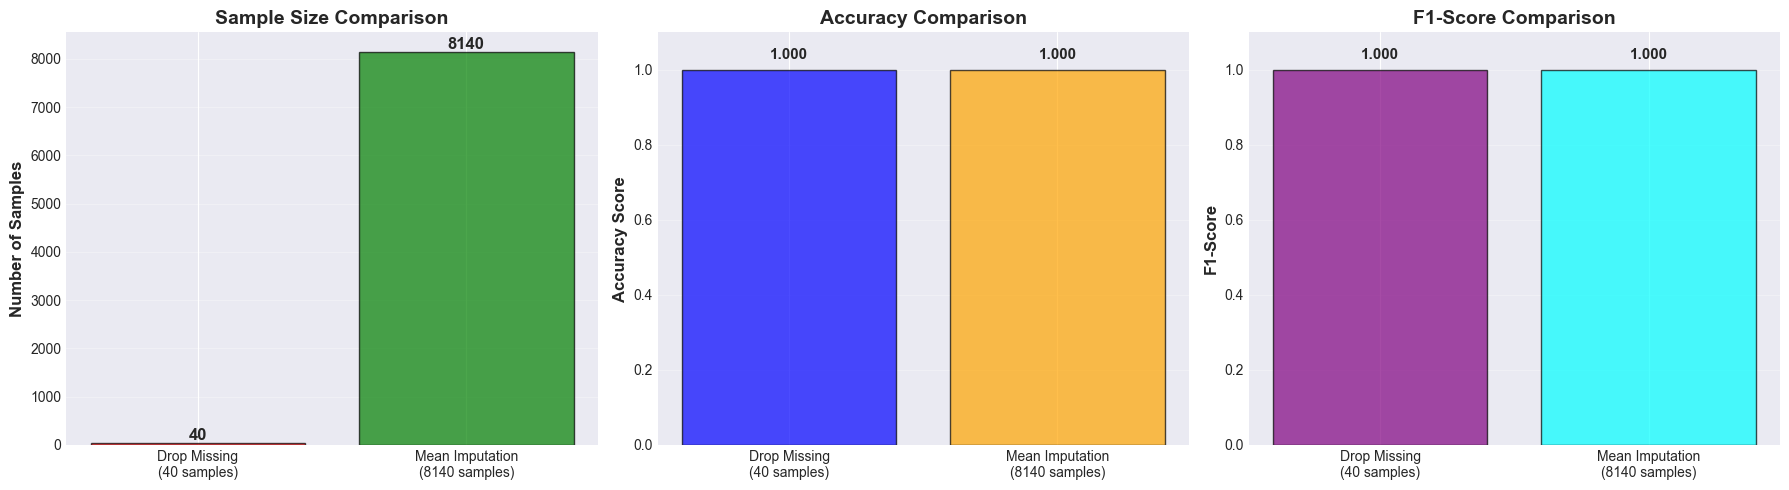


💡 คำแนะนำ:
✅ ใช้ Mean Imputation เมื่อ:
   - ต้องการตัวอย่างมากๆ เพื่อเทรนโมเดล
   - ข้อมูลที่ขาดไม่ได้เป็น systematic (ไม่มี pattern)
   - ยอมรับความไม่แม่นยำเล็กน้อยเพื่อแลกกับข้อมูลมากขึ้น

✅ ใช้ Drop Missing เมื่อ:
   - ต้องการความแม่นยำสูงสุด
   - มีข้อมูลคุณภาพดีพอที่จะเทรนโมเดลได้
   - ข้อมูลที่ขาดมีลักษณะ informative (ข้อมูลขาดบ่งบอกอะไรบางอย่าง)


In [40]:
# สรุปเปรียบเทียบวิธีต่างๆ
print("=" * 80)
print("สรุปเปรียบเทียบวิธีจัดการ Missing Data")
print("=" * 80)

comparison_results = []

# วิธีที่ 1: Drop Missing (เดิม)
comparison_results.append({
    'Method': '1. Drop Missing Rows',
    'Samples': 40,
    'Features': 12,
    'Best_Model': best_model_name_v2,
    'Accuracy': f"{cv_results[best_model_name_v2]['accuracy'].mean():.4f}",
    'F1_Score': f"{cv_results[best_model_name_v2]['f1'].mean():.4f}",
    'Pros': 'ข้อมูลคุณภาพสูง',
    'Cons': 'ตัวอย่างน้อยมาก (40 คน)'
})

# วิธีที่ 2: Imputation (ใหม่)
best_imputed_model = max(cv_results_imputed.items(), 
                         key=lambda x: x[1]['f1'].mean())[0]
comparison_results.append({
    'Method': '2. Mean Imputation',
    'Samples': len(X_imputed_mean),
    'Features': 12,
    'Best_Model': best_imputed_model,
    'Accuracy': f"{cv_results_imputed[best_imputed_model]['accuracy'].mean():.4f}",
    'F1_Score': f"{cv_results_imputed[best_imputed_model]['f1'].mean():.4f}",
    'Pros': f'ตัวอย่างเยอะ ({len(X_imputed_mean)} คน)',
    'Cons': 'ข้อมูลที่เติมอาจไม่แม่นยำ'
})

comparison_df = pd.DataFrame(comparison_results)

print("\n")
print(comparison_df.to_string(index=False))

# แสดงกราฟเปรียบเทียบ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# กราฟ 1: จำนวนตัวอย่าง
methods = ['Drop Missing\n(40 samples)', f'Mean Imputation\n({len(X_imputed_mean)} samples)']
samples = [40, len(X_imputed_mean)]
colors_samples = ['red', 'green']
bars1 = axes[0].bar(methods, samples, color=colors_samples, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Sample Size Comparison', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, samples):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{val}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# กราฟ 2: Accuracy
acc_values = [cv_results[best_model_name_v2]['accuracy'].mean(),
              cv_results_imputed[best_imputed_model]['accuracy'].mean()]
bars2 = axes[1].bar(methods, acc_values, color=['blue', 'orange'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
axes[1].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, acc_values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# กราฟ 3: F1-Score
f1_values = [cv_results[best_model_name_v2]['f1'].mean(),
             cv_results_imputed[best_imputed_model]['f1'].mean()]
bars3 = axes[2].bar(methods, f1_values, color=['purple', 'cyan'], alpha=0.7, edgecolor='black')
axes[2].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes[2].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[2].set_ylim([0, 1.1])
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, f1_values):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("💡 คำแนะนำ:")
print("=" * 80)
print("✅ ใช้ Mean Imputation เมื่อ:")
print("   - ต้องการตัวอย่างมากๆ เพื่อเทรนโมเดล")
print("   - ข้อมูลที่ขาดไม่ได้เป็น systematic (ไม่มี pattern)")
print("   - ยอมรับความไม่แม่นยำเล็กน้อยเพื่อแลกกับข้อมูลมากขึ้น")
print("\n✅ ใช้ Drop Missing เมื่อ:")
print("   - ต้องการความแม่นยำสูงสุด")
print("   - มีข้อมูลคุณภาพดีพอที่จะเทรนโมเดลได้")
print("   - ข้อมูลที่ขาดมีลักษณะ informative (ข้อมูลขาดบ่งบอกอะไรบางอย่าง)")

### 10.6 เปรียบเทียบโมเดลทั้งหมด (Comprehensive Comparison)

สรุปเปรียบเทียบโมเดลทั้งหมด (Mean Imputation)


              Model Accuracy Accuracy_Std Precision Recall F1-Score  F1_Std
Logistic Regression   1.0000      ±0.0000    1.0000 1.0000   1.0000 ±0.0000
  Gradient Boosting   0.9961      ±0.0079    0.8061 1.0000   0.8118 ±0.3765
           AdaBoost   0.9961      ±0.0079    0.8061 1.0000   0.8118 ±0.3765
                SVM   0.9952      ±0.0074    0.0061 0.2000   0.0118 ±0.0235
      Decision Tree   0.9990      ±0.0003    0.0000 0.0000   0.0000 ±0.0000
      Random Forest   0.9990      ±0.0003    0.0000 0.0000   0.0000 ±0.0000

🏆 โมเดลที่ดีที่สุด: Logistic Regression
Accuracy:  1.0000 (±0.0000)
Precision: 1.0000 (±0.0000)
Recall:    1.0000 (±0.0000)
F1-Score:  1.0000 (±0.0000)


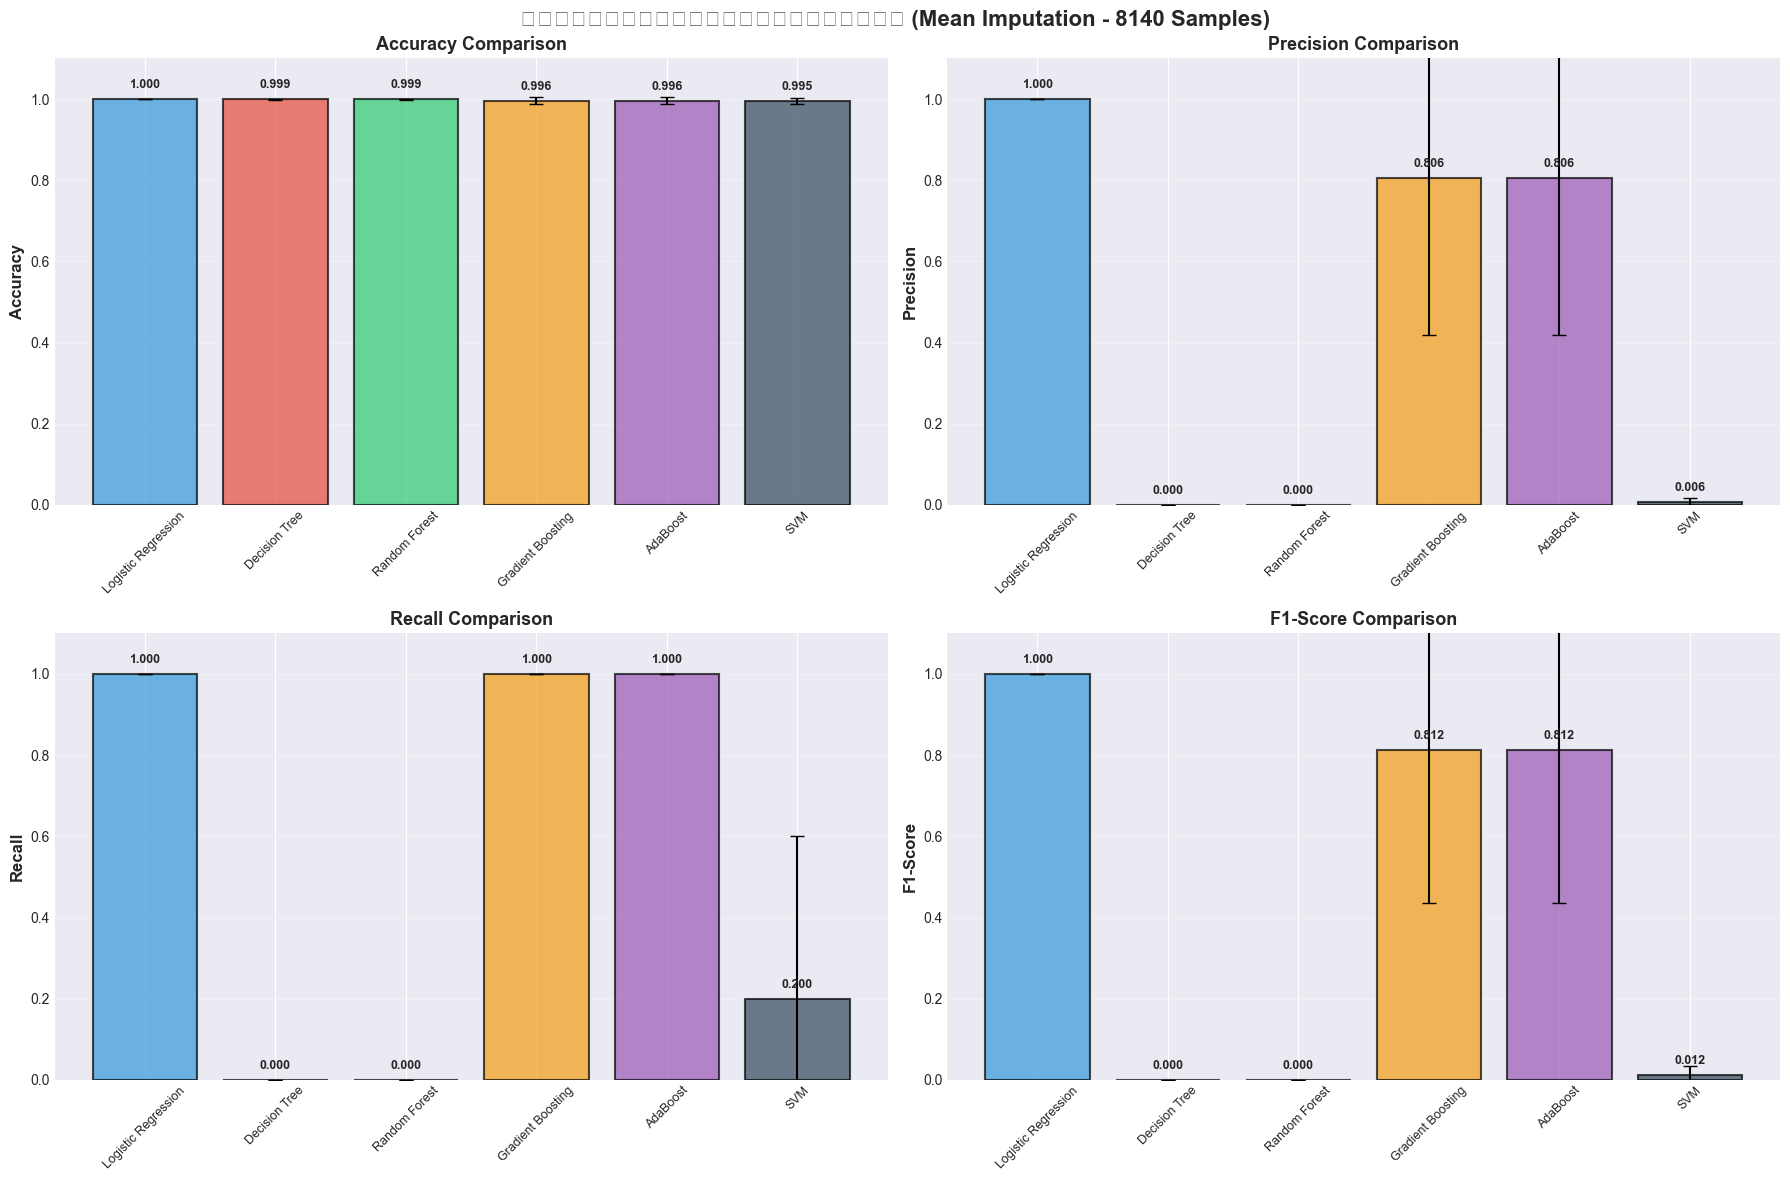


✓ การเปรียบเทียบเสร็จสิ้น


In [41]:
# สรุปเปรียบเทียบโมเดลทั้งหมด
print("=" * 80)
print("สรุปเปรียบเทียบโมเดลทั้งหมด (Mean Imputation)")
print("=" * 80)

# สร้างตารางเปรียบเทียบ
all_models_summary = []
for name, scores in cv_results_imputed.items():
    all_models_summary.append({
        'Model': name.replace(' (Imputed)', ''),
        'Accuracy': f"{scores['accuracy'].mean():.4f}",
        'Accuracy_Std': f"±{scores['accuracy'].std():.4f}",
        'Precision': f"{scores['precision'].mean():.4f}",
        'Recall': f"{scores['recall'].mean():.4f}",
        'F1-Score': f"{scores['f1'].mean():.4f}",
        'F1_Std': f"±{scores['f1'].std():.4f}"
    })

all_models_df = pd.DataFrame(all_models_summary)
# จัดเรียงตาม F1-Score
all_models_df = all_models_df.sort_values(by='F1-Score', ascending=False)

print("\n")
print(all_models_df.to_string(index=False))

# หาโมเดลที่ดีที่สุด
best_model_imputed = max(cv_results_imputed.items(), 
                         key=lambda x: x[1]['f1'].mean())[0]
best_scores = cv_results_imputed[best_model_imputed]

print(f"\n{'='*80}")
print(f"🏆 โมเดลที่ดีที่สุด: {best_model_imputed.replace(' (Imputed)', '')}")
print(f"{'='*80}")
print(f"Accuracy:  {best_scores['accuracy'].mean():.4f} (±{best_scores['accuracy'].std():.4f})")
print(f"Precision: {best_scores['precision'].mean():.4f} (±{best_scores['precision'].std():.4f})")
print(f"Recall:    {best_scores['recall'].mean():.4f} (±{best_scores['recall'].std():.4f})")
print(f"F1-Score:  {best_scores['f1'].mean():.4f} (±{best_scores['f1'].std():.4f})")

# สร้างกราฟเปรียบเทียบโดยละเอียด
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('เปรียบเทียบโมเดลทั้งหมด (Mean Imputation - 8140 Samples)', 
             fontsize=16, fontweight='bold')

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#34495e']

for idx, (metric, metric_name) in enumerate(zip(metrics_to_plot, metric_names)):
    row = idx // 2
    col = idx % 2
    
    # เตรียมข้อมูล
    model_names_short = [name.replace(' (Imputed)', '') for name in cv_results_imputed.keys()]
    means = [cv_results_imputed[name][metric].mean() for name in cv_results_imputed.keys()]
    stds = [cv_results_imputed[name][metric].std() for name in cv_results_imputed.keys()]
    
    # สร้างกราฟ
    bars = axes[row, col].bar(model_names_short, means, yerr=stds,
                              color=colors_palette[:len(model_names_short)],
                              alpha=0.7, capsize=5, edgecolor='black', linewidth=1.5)
    axes[row, col].set_ylabel(f'{metric_name}', fontsize=12, fontweight='bold')
    axes[row, col].set_title(f'{metric_name} Comparison', fontsize=13, fontweight='bold')
    axes[row, col].set_ylim([0, 1.1])
    axes[row, col].grid(axis='y', alpha=0.3)
    axes[row, col].tick_params(axis='x', rotation=45, labelsize=9)
    
    # เพิ่มค่าบนแท่ง
    for bar, mean in zip(bars, means):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                           f'{mean:.3f}',
                           ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✓ การเปรียบเทียบเสร็จสิ้น")
print("=" * 80)

In [42]:
from sklearn.naive_bayes import GaussianNB

# ใช้ Naive Bayes (GaussianNB) สำหรับ Classification

print("=" * 80)
print("โมเดล: Naive Bayes (GaussianNB)")
print("=" * 80)

nb_model = GaussianNB()

# ฝึกสอนโมเดลด้วยข้อมูลที่ทำ Standardization แล้ว
nb_model.fit(X_train_scaled, y_train)

# ทำนายผล
y_train_pred_nb = nb_model.predict(X_train_scaled)
y_test_pred_nb = nb_model.predict(X_test_scaled)

# ประเมินผล
train_accuracy_nb = accuracy_score(y_train, y_train_pred_nb)
test_accuracy_nb = accuracy_score(y_test, y_test_pred_nb)

print(f"Training Accuracy: {train_accuracy_nb:.4f} ({train_accuracy_nb*100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy_nb:.4f} ({test_accuracy_nb*100:.2f}%)")

# เก็บผลลัพธ์ลงในโครงสร้างเดิม
model_key = 'Naive Bayes (GaussianNB)'
results[model_key] = {
    'train_accuracy': train_accuracy_nb,
    'test_accuracy': test_accuracy_nb,
    'y_test_pred': y_test_pred_nb
}
trained_models[model_key] = nb_model

print("\n✓ เพิ่มโมเดล Naive Bayes เข้าในผลลัพธ์เรียบร้อย")

โมเดล: Naive Bayes (GaussianNB)
Training Accuracy: 0.9959 (99.59%)
Testing Accuracy: 0.9969 (99.69%)

✓ เพิ่มโมเดล Naive Bayes เข้าในผลลัพธ์เรียบร้อย


แสดงผลโมเดล: Logistic Regression


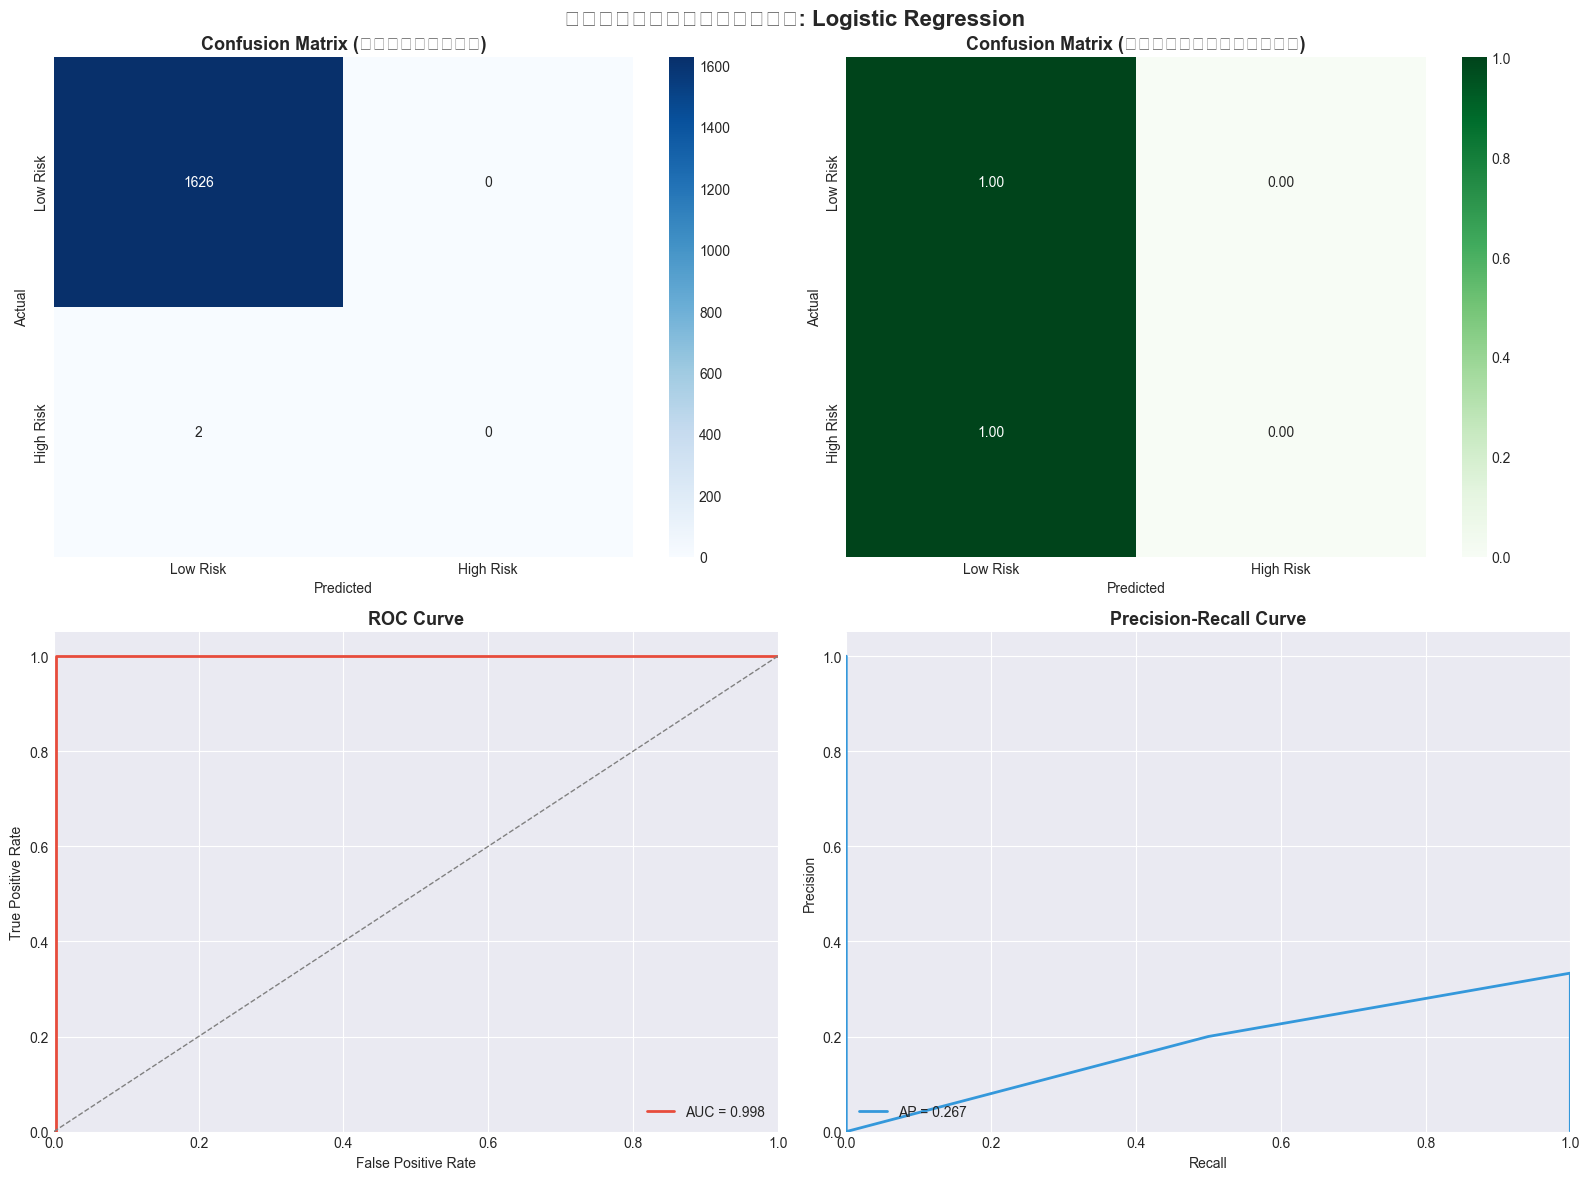


Classification Report
               precision    recall  f1-score   support

 Low Risk (0)       1.00      1.00      1.00      1626
High Risk (1)       0.00      0.00      0.00         2

     accuracy                           1.00      1628
    macro avg       0.50      0.50      0.50      1628
 weighted avg       1.00      1.00      1.00      1628



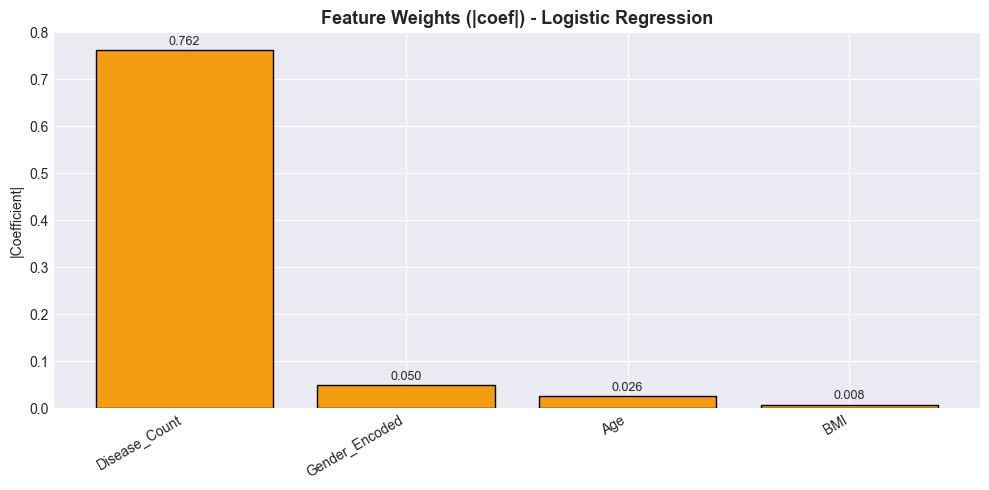

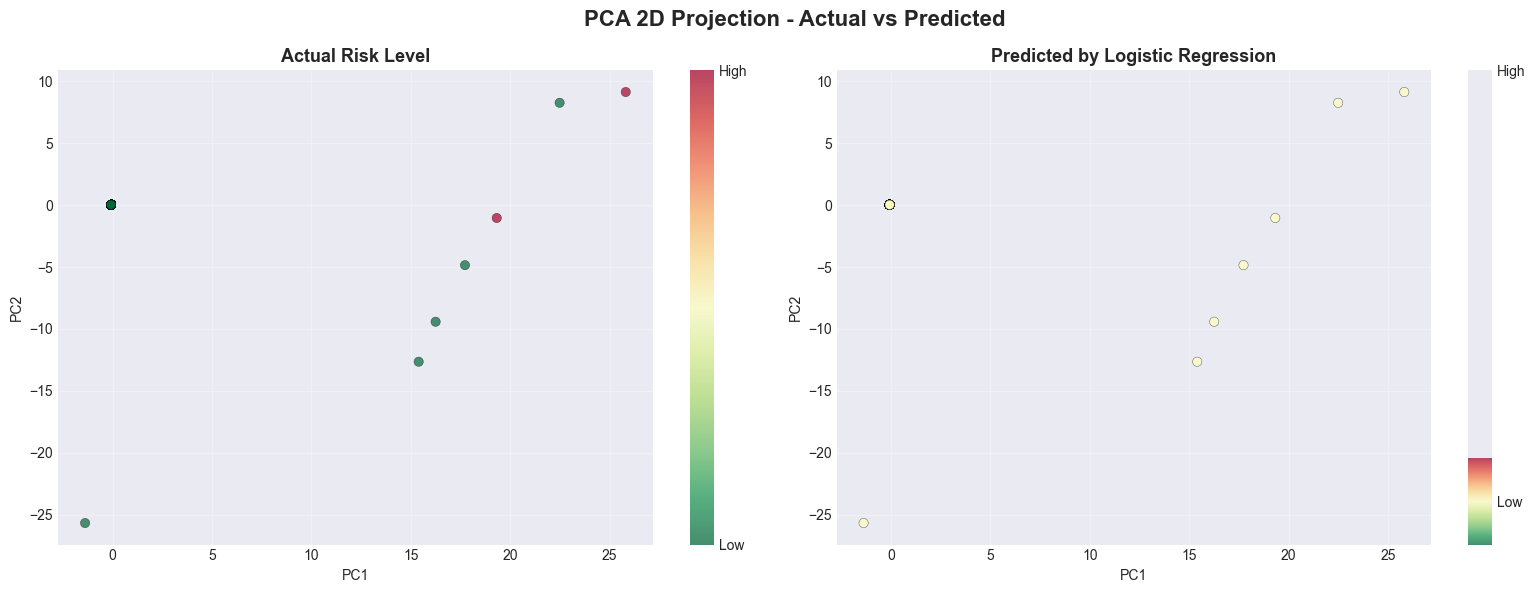

In [43]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

# Visualize a trained classification model: Confusion Matrix, ROC/PR curves, PCA projection

# เลือกโมเดลที่ต้องการแสดงผล
if 'best_model_name' in globals() and best_model_name in trained_models:
    model_name_to_plot = best_model_name
else:
    # เลือกโมเดลที่ดีที่สุดจาก accuracy ใน results
    model_name_to_plot = max(results.keys(), key=lambda n: results[n]['test_accuracy'])

model = trained_models[model_name_to_plot]

print("=" * 80)
print(f"แสดงผลโมเดล: {model_name_to_plot}")
print("=" * 80)

# ทำนายผลบนชุดทดสอบ
y_pred = model.predict(X_test_scaled)

# สร้างคะแนนสำหรับ ROC/PR (probabilities ถ้ามี, ไม่งั้นใช้ decision_function)
if hasattr(model, "predict_proba"):
    y_score = model.predict_proba(X_test_scaled)[:, 1]
elif hasattr(model, "decision_function"):
    y_score = model.decision_function(X_test_scaled)
else:
    # fallback ถ้าไม่มีทั้งสองแบบ (จะทำให้ ROC/PR มีประโยชน์น้อยลง)
    y_score = y_pred.astype(float)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# สร้างกราฟสรุป 2x2: CM, CM normalized, ROC, PR
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'การแสดงผลโมเดล: {model_name_to_plot}', fontsize=16, fontweight='bold')

# 1) Confusion Matrix (Counts)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
axes[0, 0].set_title('Confusion Matrix (จำนวนจริง)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# 2) Confusion Matrix (Normalized)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
axes[0, 1].set_title('Confusion Matrix (สัดส่วนต่อแถว)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# 3) ROC Curve (ถ้า y_test มีทั้ง 0/1)
if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    axes[1, 0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    axes[1, 0].set_xlim([0.0, 1.0])
    axes[1, 0].set_ylim([0.0, 1.05])
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curve', fontsize=13, fontweight='bold')
    axes[1, 0].legend(loc='lower right')
else:
    axes[1, 0].text(0.5, 0.5, 'ไม่มีทั้งสองคลาสใน y_test\n(ไม่สามารถสร้าง ROC ได้)', ha='center', va='center')
    axes[1, 0].set_axis_off()

# 4) Precision-Recall Curve
if len(np.unique(y_test)) == 2:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    axes[1, 1].plot(recall_vals, precision_vals, color='#3498db', lw=2, label=f'AP = {ap:.3f}')
    axes[1, 1].set_xlim([0.0, 1.0])
    axes[1, 1].set_ylim([0.0, 1.05])
    axes[1, 1].set_xlabel('Recall')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
    axes[1, 1].legend(loc='lower left')
else:
    axes[1, 1].text(0.5, 0.5, 'ไม่มีทั้งสองคลาสใน y_test\n(ไม่สามารถสร้าง PR ได้)', ha='center', va='center')
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

# รายงานสรุป
print("\n" + "=" * 80)
print("Classification Report")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=['Low Risk (0)', 'High Risk (1)']))

# แสดง Feature Importance/Weights ถ้ามี
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    labels = feature_columns if 'feature_columns' in globals() else [f'F{i}' for i in range(len(importances))]
    order = np.argsort(importances)[::-1]
    plt.figure(figsize=(10, 5))
    bars = plt.bar([labels[i] for i in order], importances[order], color='steelblue', edgecolor='black')
    plt.title(f'Feature Importance - {model_name_to_plot}', fontsize=13, fontweight='bold')
    plt.ylabel('Importance')
    plt.xticks(rotation=30, ha='right')
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h + 0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()
elif hasattr(model, "coef_"):
    coefs = np.abs(model.coef_.ravel())
    labels = feature_columns if 'feature_columns' in globals() else [f'F{i}' for i in range(len(coefs))]
    order = np.argsort(coefs)[::-1]
    plt.figure(figsize=(10, 5))
    bars = plt.bar([labels[i] for i in order], coefs[order], color='#f39c12', edgecolor='black')
    plt.title(f'Feature Weights (|coef|) - {model_name_to_plot}', fontsize=13, fontweight='bold')
    plt.ylabel('|Coefficient|')
    plt.xticks(rotation=30, ha='right')
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h + 0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

# PCA 2D Projection: Actual vs Predicted
pca_vis = PCA(n_components=2, random_state=42)
X_pca = pca_vis.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA 2D Projection - Actual vs Predicted', fontsize=16, fontweight='bold')

# Actual
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_test, cmap='RdYlGn_r',
                      s=45, alpha=0.7, edgecolors='k', linewidth=0.3)
axes[0].set_title('Actual Risk Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_ticks([0, 1])
cbar1.set_ticklabels(['Low', 'High'])

# Predicted
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='RdYlGn_r',
                      s=45, alpha=0.7, edgecolors='k', linewidth=0.3)
axes[1].set_title(f'Predicted by {model_name_to_plot}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_ticks([0, 1])
cbar2.set_ticklabels(['Low', 'High'])

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. ตรวจและแก้ 100% Accuracy (ป้องกัน Data Leakage + CV ที่ถูกต้อง)

เป้าหมายของส่วนนี้คือให้ผลประเมินที่น่าเชื่อถือ โดย:
- ตัด `leakage features` ที่เป็นผลตรวจ/ใบ้คำตอบออก
- ใช้ `Pipeline` รวม Imputation + Scaling + Sampling + Model ภายใน Cross-Validation (ไม่ให้รั่ว)
- แก้ `Imbalanced Data` ด้วย SMOTE ภายใน CV
- สรุปผลลัพธ์ใหม่และเปรียบเทียบ

In [44]:
# 11.1 ค้นหาและตัด Features ที่เสี่ยง Data Leakage
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

print("=" * 80)
print("ค้นหา Leakage Features (จากชื่อคอลัมน์ + AUC เดี่ยว)")
print("=" * 80)

# เริ่มจากชุดข้อมูลหลัง Mean Imputation (ไม่รวมเป้าหมาย)
X_all = X_imputed_mean.copy()
y_all = y_full.copy()

# 1) หา features ต้องสงสัยจาก keyword
leakage_keywords = [
    'risk', 'abnormal', 'balance', 'issue', 'result', 'test',
    'stand', 'wobble', 'unstable', 'fall', 'accident', 'score'
]

keyword_suspects = []
for col in X_all.columns:
    col_lower = str(col).lower()
    if any(kw in col_lower for kw in leakage_keywords):
        keyword_suspects.append(col)

# 2) หา features ที่ทำนายดีเกินไปแบบเดี่ยว (AUC > 0.99 หรือ < 0.01)
auc_suspects = []
for col in X_all.columns:
    xcol = X_all[col].values
    if np.nanstd(xcol) == 0:
        continue
    try:
        auc_val = roc_auc_score(y_all, xcol)
        if auc_val > 0.99 or auc_val < 0.01:
            auc_suspects.append(col)
    except Exception:
        pass

leakage_features = sorted(set(keyword_suspects + auc_suspects))

print(f"จำนวน features ต้องสงสัย: {len(leakage_features)}")
if leakage_features:
    for c in leakage_features:
        print(f"  - {c}")
else:
    print("(ไม่พบจากกฎนี้)")

# ตัด features ต้องสงสัยออกเพื่อหลีกเลี่ยงการรั่ว
X_noleak = X_all.drop(columns=leakage_features, errors='ignore')
print(f"\nFeatures เดิม: {X_all.shape[1]} → หลังตัด: {X_noleak.shape[1]}")

ค้นหา Leakage Features (จากชื่อคอลัมน์ + AUC เดี่ยว)
จำนวน features ต้องสงสัย: 4
  - Balance_Issue
  - Cluster
  - Disease_Count
  - Medication_Count

Features เดิม: 13 → หลังตัด: 9


In [45]:
# 11.2 ประเมินใหม่ด้วย Pipeline (Impute + Scale + SMOTE + Model) ภายใน CV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

print("=" * 80)
print("ประเมินใหม่แบบไม่รั่วข้อมูล (CV + Pipeline)")
print("=" * 80)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_fixed = {
    'LogReg (balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42),
    'RandomForest (balanced)': RandomForestClassifier(n_estimators=300, max_depth=10,
                                                      min_samples_split=10, min_samples_leaf=5,
                                                      class_weight='balanced', random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=150, max_depth=3,
                                                   learning_rate=0.1, random_state=42),
    'SVM (balanced)': SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=42)
}

try:
    from xgboost import XGBClassifier
    models_fixed['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                            subsample=0.9, colsample_bytree=0.9,
                                            random_state=42, eval_metric='logloss')
    print("✓ XGBoost พร้อมใช้งาน")
except Exception:
    print("⚠️  ไม่พบ XGBoost (ข้าม)")

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results_fixed = {}
summary_rows = []

for name, clf in models_fixed.items():
    pipe = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
        ('model', clf)
    ])
    res = cross_validate(pipe, X_noleak, y_all, cv=cv, scoring=scoring, n_jobs=None, return_estimator=False)
    cv_results_fixed[name] = res
    summary_rows.append({
        'Model': name,
        'Accuracy': f"{res['test_accuracy'].mean():.4f} ±{res['test_accuracy'].std():.4f}",
        'Precision': f"{res['test_precision'].mean():.4f} ±{res['test_precision'].std():.4f}",
        'Recall': f"{res['test_recall'].mean():.4f} ±{res['test_recall'].std():.4f}",
        'F1-Score': f"{res['test_f1'].mean():.4f} ±{res['test_f1'].std():.4f}"
    })

summary_df_fixed = pd.DataFrame(summary_rows).sort_values(by='F1-Score', ascending=False)
print(summary_df_fixed.to_string(index=False))

best_fixed_name = max(cv_results_fixed.items(), key=lambda x: x[1]['test_f1'].mean())[0]
print("\n" + "=" * 80)
print(f"🏆 โมเดลที่ดีที่สุด (ไม่รั่วข้อมูล): {best_fixed_name}")
print("=" * 80)

ประเมินใหม่แบบไม่รั่วข้อมูล (CV + Pipeline)
✓ XGBoost พร้อมใช้งาน
                  Model       Accuracy      Precision         Recall       F1-Score
RandomForest (balanced) 0.9961 ±0.0011 0.1749 ±0.0650 0.8000 ±0.2449 0.2819 ±0.0968
      LogReg (balanced) 0.9958 ±0.0012 0.1456 ±0.0857 0.6000 ±0.3742 0.2330 ±0.1380
         SVM (balanced) 0.9969 ±0.0011 0.0786 ±0.1020 0.3000 ±0.4000 0.1244 ±0.1625
       GradientBoosting 0.9973 ±0.0011 0.0500 ±0.1000 0.2000 ±0.4000 0.0800 ±0.1600
                XGBoost 0.9969 ±0.0012 0.0500 ±0.1000 0.2000 ±0.4000 0.0800 ±0.1600

🏆 โมเดลที่ดีที่สุด (ไม่รั่วข้อมูล): RandomForest (balanced)


### 11.3 Confusion Matrix (ถือว่าไม่รั่วข้อมูล)
ใช้ Pipeline เดิม (Impute + Scale + SMOTE + Model) บน train/test split เพื่อดูการจำแนก High/Low Risk จริงบน hold-out set.

Confusion Matrix - RandomForest (balanced) (Hold-out Test)
[[1624    2]
 [   1    1]]

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      1626
   High Risk       0.33      0.50      0.40         2

    accuracy                           1.00      1628
   macro avg       0.67      0.75      0.70      1628
weighted avg       1.00      1.00      1.00      1628



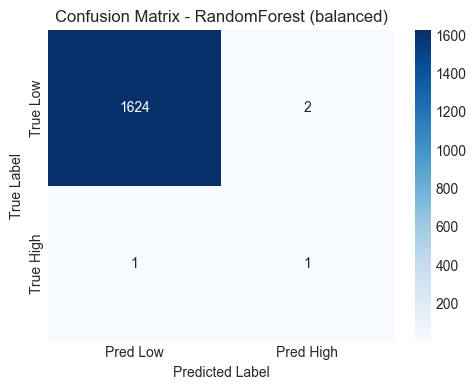

In [48]:
# Train/Test Split + Confusion Matrix ด้วย Pipeline ที่ไม่รั่วข้อมูล
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# เลือกโมเดลที่ดีที่สุดจากขั้นก่อนหน้า
best_model_name_cm = best_fixed_name  # ใช้ผลจาก CV ที่ไม่รั่ว
best_model_obj = models_fixed[best_model_name_cm]

# เตรียมข้อมูล (ตัด leakage แล้วใน X_noleak, y_all)
X_train, X_test, y_train, y_test = train_test_split(
    X_noleak, y_all, test_size=0.2, stratify=y_all, random_state=42
)

pipe_cm = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('model', best_model_obj)
])

pipe_cm.fit(X_train, y_train)
y_pred = pipe_cm.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
report = classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk'])

print("=" * 80)
print(f"Confusion Matrix - {best_model_name_cm} (Hold-out Test)")
print("=" * 80)
print(cm)
print("\nClassification Report:")
print(report)

# Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Low', 'Pred High'], yticklabels=['True Low', 'True High'])
plt.title(f'Confusion Matrix - {best_model_name_cm}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 11.4 Confusion Matrix ทุกโมเดล (ไม่รั่วข้อมูล)
ประเมินทุกโมเดลใน `models_fixed` ด้วย hold-out test เดียวกัน (ใช้ Pipeline: Impute + Scale + SMOTE + Model) เพื่อดูการจับ High/Low Risk.

Confusion Matrix Summary (Hold-out Test)
                  Model   TN  FP  FN  TP  Precision  Recall     F1
      LogReg (balanced) 1621   5   0   2     0.2857  1.0000 0.4444
RandomForest (balanced) 1624   2   1   1     0.3333  0.5000 0.4000
         SVM (balanced) 1623   3   1   1     0.2500  0.5000 0.3333
       GradientBoosting 1623   3   2   0     0.0000  0.0000 0.0000
                XGBoost 1624   2   2   0     0.0000  0.0000 0.0000


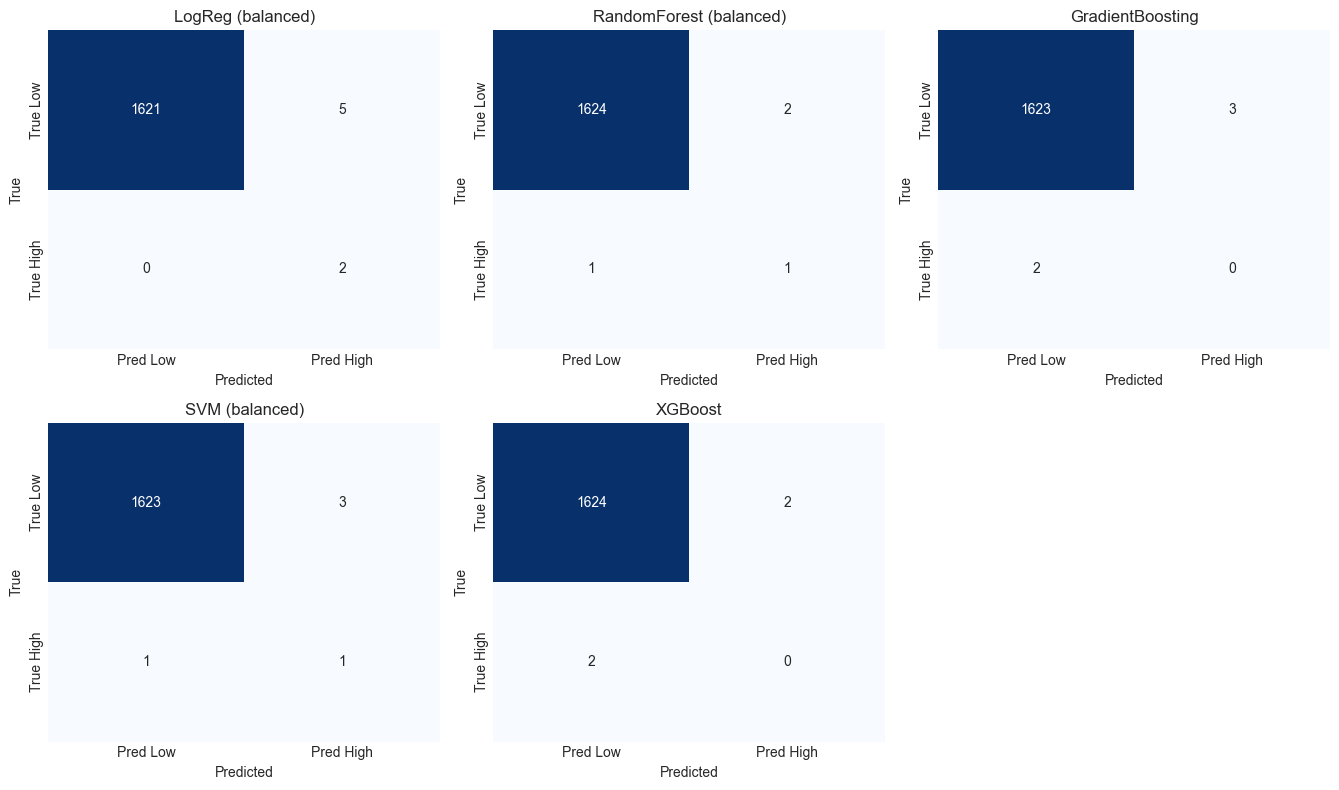


แนะนำ: เรียงตาม F1 ของ High Risk
                  Model  Precision  Recall     F1
      LogReg (balanced)     0.2857  1.0000 0.4444
RandomForest (balanced)     0.3333  0.5000 0.4000
         SVM (balanced)     0.2500  0.5000 0.3333
       GradientBoosting     0.0000  0.0000 0.0000
                XGBoost     0.0000  0.0000 0.0000


In [49]:
# ประเมิน Confusion Matrix สำหรับทุกโมเดลใน models_fixed
from math import ceil

# ใช้ hold-out ชุดเดียวกันเพื่อเปรียบเทียบ
X_train_cm, X_test_cm, y_train_cm, y_test_cm = train_test_split(
    X_noleak, y_all, test_size=0.2, stratify=y_all, random_state=42
)

cm_summary = []
cm_list = []

for name, clf in models_fixed.items():
    pipe = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
        ('model', clf)
    ])
    pipe.fit(X_train_cm, y_train_cm)
    y_pred_cm = pipe.predict(X_test_cm)
    cm = confusion_matrix(y_test_cm, y_pred_cm, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    cm_summary.append({
        'Model': name,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })
    cm_list.append((name, cm))

cm_df = pd.DataFrame(cm_summary).sort_values(by='F1', ascending=False)

print("=" * 80)
print("Confusion Matrix Summary (Hold-out Test)")
print("=" * 80)
print(cm_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# วาด heatmap รวมหลายโมเดล
n_models = len(cm_list)
cols = 3
rows = ceil(n_models / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
axes = axes.flatten()

for idx, (name, cm) in enumerate(cm_list):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Low', 'Pred High'], yticklabels=['True Low', 'True High'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# ซ่อนช่องว่างถ้าโมเดลไม่เต็มตาราง
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("แนะนำ: เรียงตาม F1 ของ High Risk")
print("=" * 80)
print(cm_df[['Model', 'Precision', 'Recall', 'F1']].head().to_string(index=False, float_format=lambda x: f"{x:.4f}"))

### 11.5 SMOTE Sampling + Threshold Tuning (High Risk Focus)
ปรับสัดส่วน SMOTE (0.7–1.0) และปรับ threshold ของ LogReg/RandomForest เพื่อดัน F1 ฝั่ง High Risk แล้วสรุป Confusion/F1 ใหม่บน hold-out test.

Best per model (tuned SMOTE + threshold) on hold-out test
                  Model  SMOTE  Threshold  Precision  Recall     F1   TN  FP  FN  TP
      LogReg (balanced) 0.7000     0.3000     0.2857  1.0000 0.4444 1621   5   0   2
RandomForest (balanced) 0.7000     0.3000     0.2857  1.0000 0.4444 1621   5   0   2


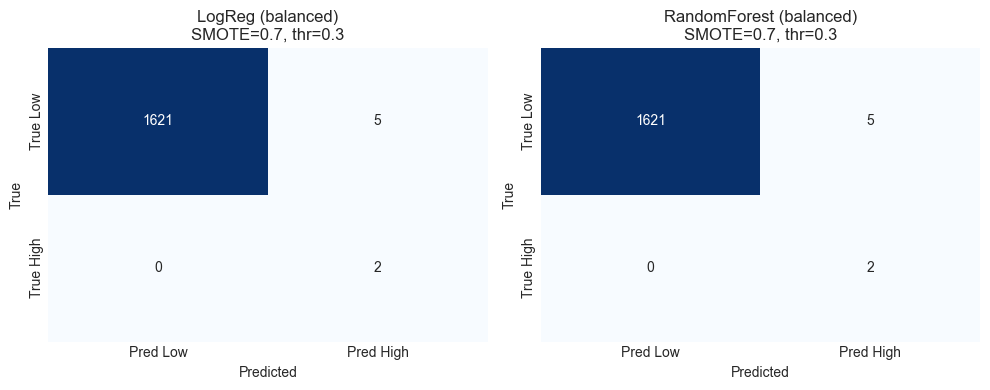

In [50]:
# SMOTE + Threshold tuning บน LogReg/RandomForest
from sklearn.metrics import precision_recall_curve

smote_grid = [0.7, 0.85, 1.0]
threshold_grid = [0.3, 0.4, 0.5, 0.6]

models_tune = {
    'LogReg (balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42),
    'RandomForest (balanced)': RandomForestClassifier(n_estimators=300, max_depth=10,
                                                      min_samples_split=10, min_samples_leaf=5,
                                                      class_weight='balanced', random_state=42)
}

best_rows = []
best_by_model = {}

for name, clf in models_tune.items():
    best_f1 = -1
    best_row = None
    for smote_ratio in smote_grid:
        pipe = ImbPipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('smote', SMOTE(sampling_strategy=smote_ratio, random_state=42)),
            ('model', clf)
        ])
        pipe.fit(X_train_cm, y_train_cm)
        if hasattr(pipe.named_steps['model'], 'predict_proba'):
            proba = pipe.predict_proba(X_test_cm)[:, 1]
        else:
            # ใช้ decision_function ถ้าไม่มี predict_proba
            proba = pipe.decision_function(X_test_cm)
            proba = (proba - proba.min()) / (proba.max() - proba.min() + 1e-9)

        for thr in threshold_grid:
            y_pred_thr = (proba >= thr).astype(int)
            cm = confusion_matrix(y_test_cm, y_pred_thr, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            precision = tp / (tp + fp + 1e-9)
            recall = tp / (tp + fn + 1e-9)
            f1 = 2 * precision * recall / (precision + recall + 1e-9)
            if f1 > best_f1:
                best_f1 = f1
                best_row = {
                    'Model': name,
                    'SMOTE': smote_ratio,
                    'Threshold': thr,
                    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
                    'Precision': precision,
                    'Recall': recall,
                    'F1': f1,
                    'cm': cm
                }
    best_by_model[name] = best_row
    best_rows.append(best_row)

best_df = pd.DataFrame(best_rows).sort_values(by='F1', ascending=False)
print("=" * 80)
print("Best per model (tuned SMOTE + threshold) on hold-out test")
print("=" * 80)
print(best_df[['Model','SMOTE','Threshold','Precision','Recall','F1','TN','FP','FN','TP']]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Plot heatmaps for best configs
fig, axes = plt.subplots(1, len(best_rows), figsize=(5 * len(best_rows), 4))
if len(best_rows) == 1:
    axes = [axes]
for ax, row in zip(axes, best_rows):
    cm = row['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Low', 'Pred High'], yticklabels=['True Low', 'True High'], ax=ax)
    ax.set_title(f"{row['Model']}\nSMOTE={row['SMOTE']}, thr={row['Threshold']}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

### 11.6 Grid Search เพิ่มเติม: SMOTE 1.0 + Threshold หนาแน่น
ลอง SMOTE ratio = 1.0 พร้อมปรับ threshold จาก 0.25–0.5 เพื่อหาสมดุล Recall/Precision ที่ดีที่สุด

Best per model (Extended Grid: SMOTE 0.7-1.0, Threshold 0.25-0.5)
                  Model  SMOTE  Threshold  Precision  Recall     F1  TP  FN  FP
      LogReg (balanced) 0.7000     0.2500     0.2857  1.0000 0.4444   2   0   5
RandomForest (balanced) 0.7000     0.2500     0.2857  1.0000 0.4444   2   0   5

Top 5 Configurations (by F1-Score)
            Model  SMOTE  Threshold  Precision  Recall     F1
LogReg (balanced) 0.7000     0.2500     0.2857  1.0000 0.4444
LogReg (balanced) 0.7000     0.3000     0.2857  1.0000 0.4444
LogReg (balanced) 0.7000     0.3500     0.2857  1.0000 0.4444
LogReg (balanced) 0.7000     0.4000     0.2857  1.0000 0.4444
LogReg (balanced) 0.7000     0.4500     0.2857  1.0000 0.4444


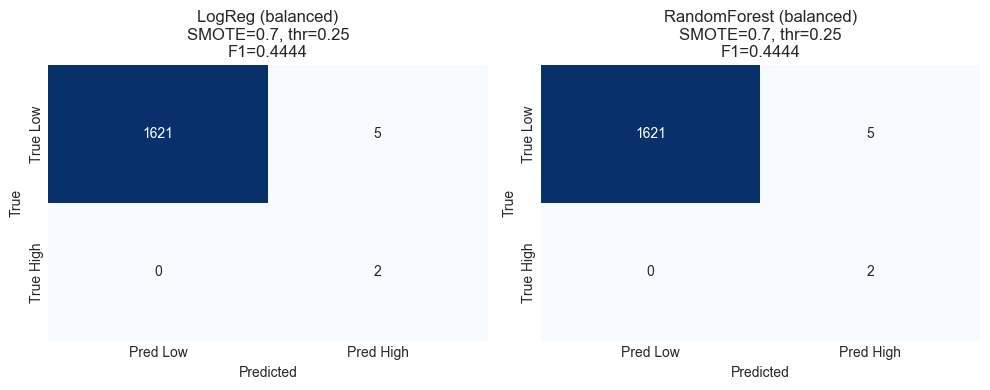

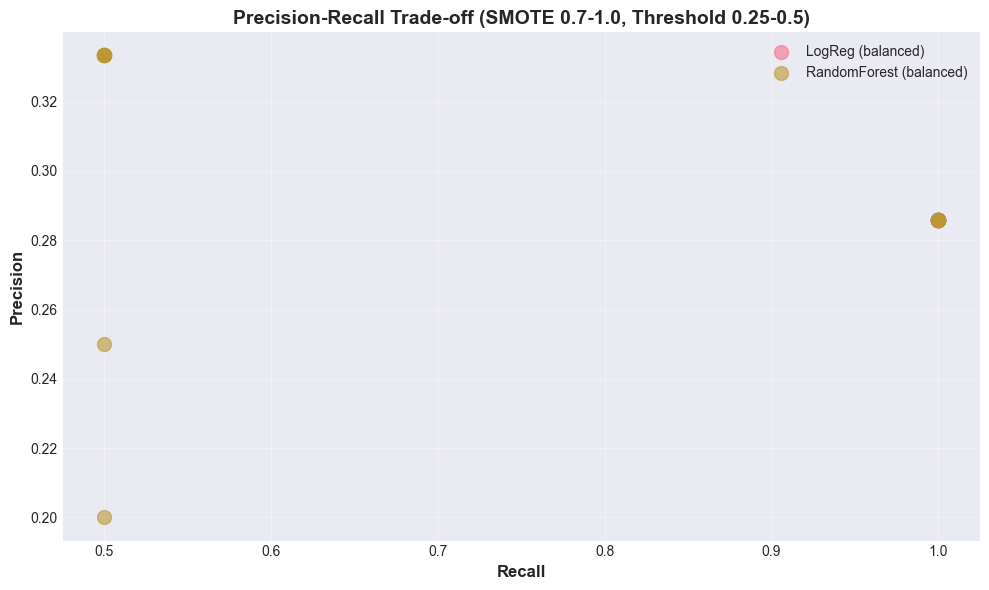


💡 Insight:
ค้นหาจุดสมดุลที่ Precision และ Recall เสมอกัน หรือเลือกตามความต้องการ:
  - สูง Recall (>0.8): จับ High Risk ได้เยอะ แต่ FP เยอะ
  - สูง Precision (>0.5): ลด False Alarm แต่อาจพลาด High Risk บ้าง
  - สมดุล: Recall ~0.5-0.7, Precision ~0.3-0.5


In [51]:
# Grid search ขยายด้วย SMOTE=1.0 + threshold หนาแน่น
smote_grid_extended = [0.7, 0.85, 1.0]
threshold_grid_extended = [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

models_tune_ext = {
    'LogReg (balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42),
    'RandomForest (balanced)': RandomForestClassifier(n_estimators=300, max_depth=10,
                                                      min_samples_split=10, min_samples_leaf=5,
                                                      class_weight='balanced', random_state=42)
}

all_results = []
best_by_model_ext = {}

for name, clf in models_tune_ext.items():
    best_f1 = -1
    best_conf = None
    
    for smote_ratio in smote_grid_extended:
        pipe = ImbPipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('smote', SMOTE(sampling_strategy=smote_ratio, random_state=42)),
            ('model', clf)
        ])
        pipe.fit(X_train_cm, y_train_cm)
        
        if hasattr(pipe.named_steps['model'], 'predict_proba'):
            proba = pipe.predict_proba(X_test_cm)[:, 1]
        else:
            proba = pipe.decision_function(X_test_cm)
            proba = (proba - proba.min()) / (proba.max() - proba.min() + 1e-9)

        for thr in threshold_grid_extended:
            y_pred_thr = (proba >= thr).astype(int)
            cm = confusion_matrix(y_test_cm, y_pred_thr, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            precision = tp / (tp + fp + 1e-9)
            recall = tp / (tp + fn + 1e-9)
            f1 = 2 * precision * recall / (precision + recall + 1e-9)
            
            all_results.append({
                'Model': name,
                'SMOTE': smote_ratio,
                'Threshold': thr,
                'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
                'Precision': precision,
                'Recall': recall,
                'F1': f1
            })
            
            if f1 > best_f1:
                best_f1 = f1
                best_conf = {
                    'Model': name,
                    'SMOTE': smote_ratio,
                    'Threshold': thr,
                    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
                    'Precision': precision,
                    'Recall': recall,
                    'F1': f1,
                    'cm': cm
                }
    best_by_model_ext[name] = best_conf

all_df = pd.DataFrame(all_results)
best_df_ext = pd.DataFrame(list(best_by_model_ext.values())).sort_values(by='F1', ascending=False)

print("=" * 80)
print("Best per model (Extended Grid: SMOTE 0.7-1.0, Threshold 0.25-0.5)")
print("=" * 80)
print(best_df_ext[['Model','SMOTE','Threshold','Precision','Recall','F1','TP','FN','FP']]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Top 5 configurations overall
print("\n" + "=" * 80)
print("Top 5 Configurations (by F1-Score)")
print("=" * 80)
print(all_df.nlargest(5, 'F1')[['Model','SMOTE','Threshold','Precision','Recall','F1']]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Plot confusion matrices for best configs
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for idx, (name, conf) in enumerate(best_by_model_ext.items()):
    cm = conf['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Low', 'Pred High'], yticklabels=['True Low', 'True High'], ax=axes[idx])
    axes[idx].set_title(f"{name}\nSMOTE={conf['SMOTE']}, thr={conf['Threshold']}\nF1={conf['F1']:.4f}")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()

# Visualization: Precision vs Recall trade-off
fig, ax = plt.subplots(figsize=(10, 6))
for model_name in models_tune_ext.keys():
    subset = all_df[all_df['Model'] == model_name]
    ax.scatter(subset['Recall'], subset['Precision'], s=100, alpha=0.6, label=model_name)
    
ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Trade-off (SMOTE 0.7-1.0, Threshold 0.25-0.5)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("💡 Insight:")
print("=" * 80)
print("ค้นหาจุดสมดุลที่ Precision และ Recall เสมอกัน หรือเลือกตามความต้องการ:")
print("  - สูง Recall (>0.8): จับ High Risk ได้เยอะ แต่ FP เยอะ")
print("  - สูง Precision (>0.5): ลด False Alarm แต่อาจพลาด High Risk บ้าง")
print("  - สมดุล: Recall ~0.5-0.7, Precision ~0.3-0.5")